In [1]:
# we're trying to objectify inductive and elaborate on the system from there.

In [1]:
from taskManagerV02 import *

In [2]:
def print_arrays(case_num):
    this_task = TaskManager(tt[case_num])
    this_task.brief_task()
    return this_task

In [3]:
from pathlib import Path
data_path = Path('/Users/hassanshallal/Desktop/abstract_reasoning_dataset/abstraction-and-reasoning-challenge/')
training_path = data_path / 'training'
tt = load_set(training_path)

1
solved


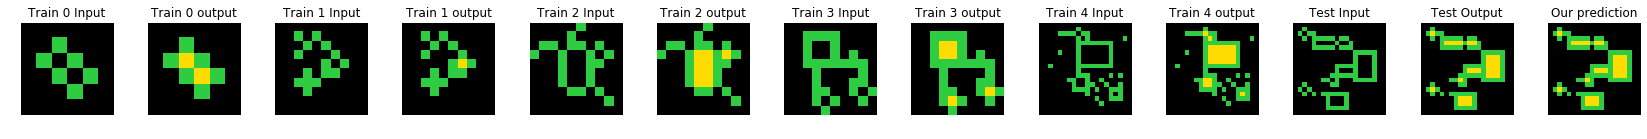

^^^^^^^^^^^^^^^^^^^
43
partially solved


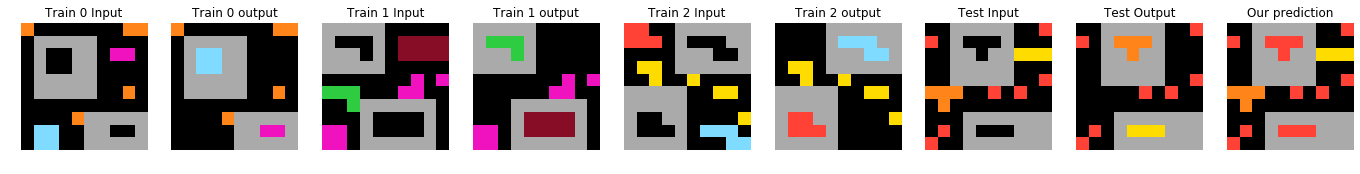

^^^^^^^^^^^^^^^^^^^
84
partially solved


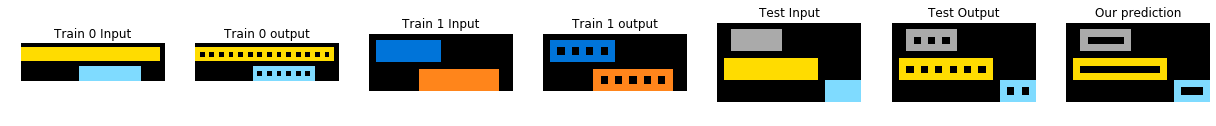

^^^^^^^^^^^^^^^^^^^
86
solved


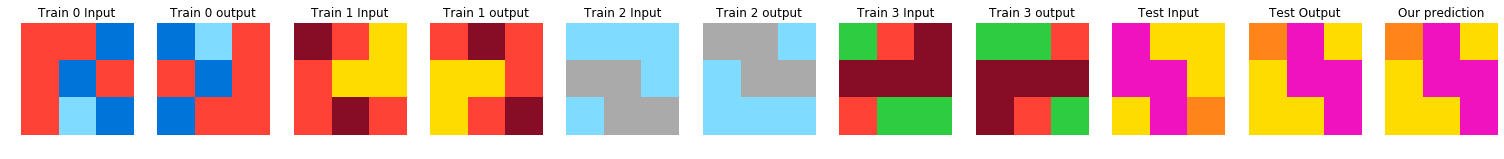

^^^^^^^^^^^^^^^^^^^
97
solved


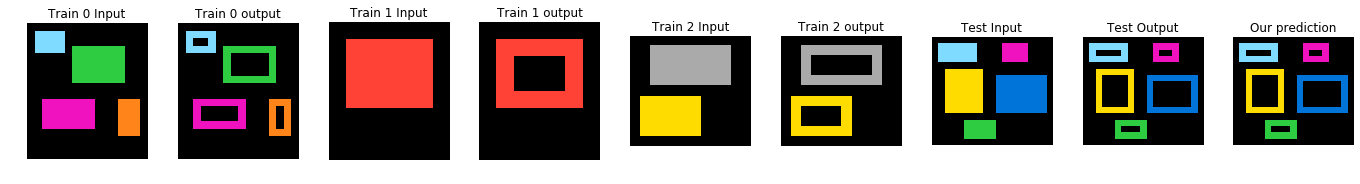

^^^^^^^^^^^^^^^^^^^
101
partially solved


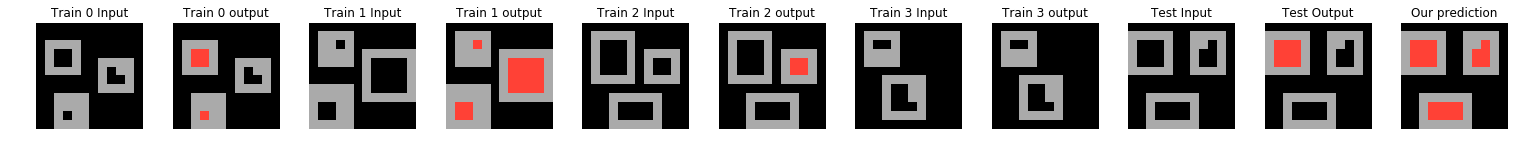

^^^^^^^^^^^^^^^^^^^
119
solved


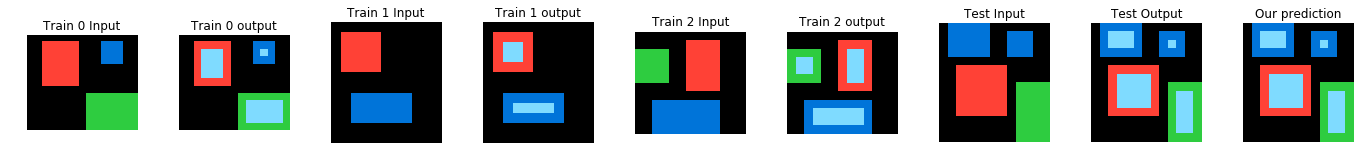

^^^^^^^^^^^^^^^^^^^
124
partially solved


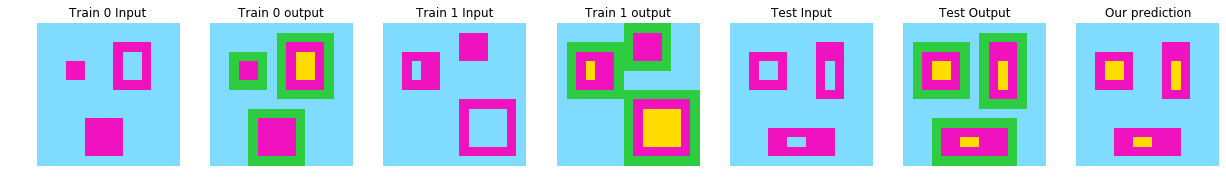

^^^^^^^^^^^^^^^^^^^
139
solved


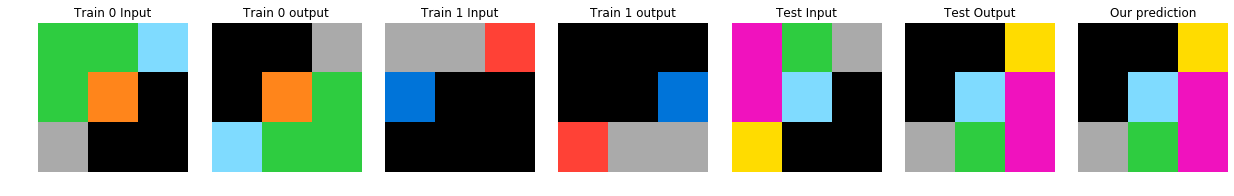

^^^^^^^^^^^^^^^^^^^
142
partially solved


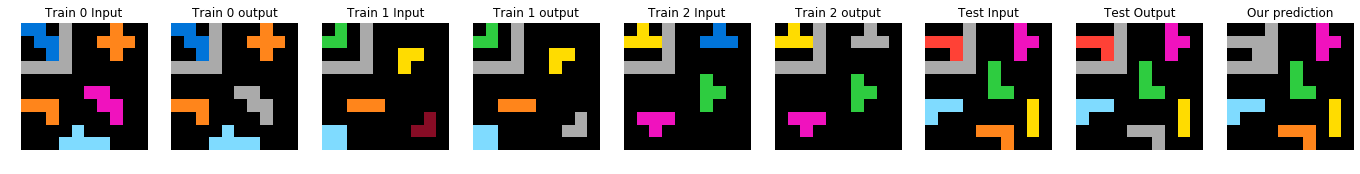

^^^^^^^^^^^^^^^^^^^
149
solved


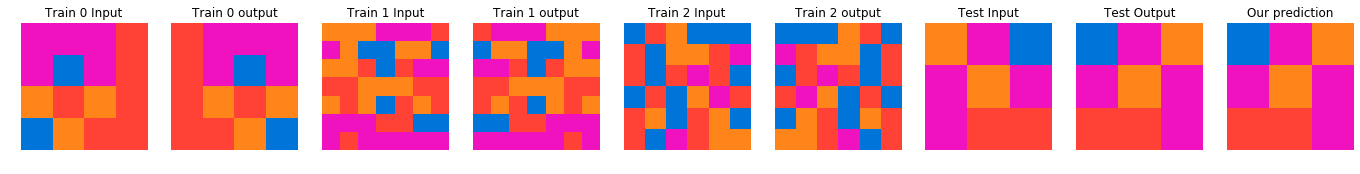

^^^^^^^^^^^^^^^^^^^
154
solved


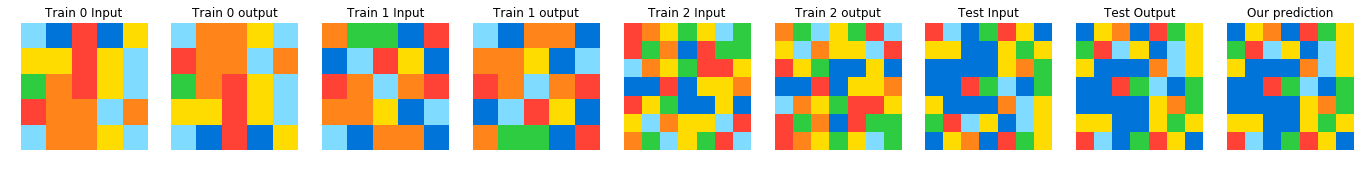

^^^^^^^^^^^^^^^^^^^
155
partially solved


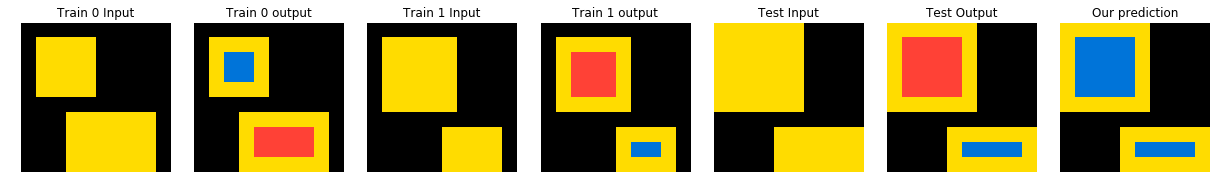

^^^^^^^^^^^^^^^^^^^
159
partially solved


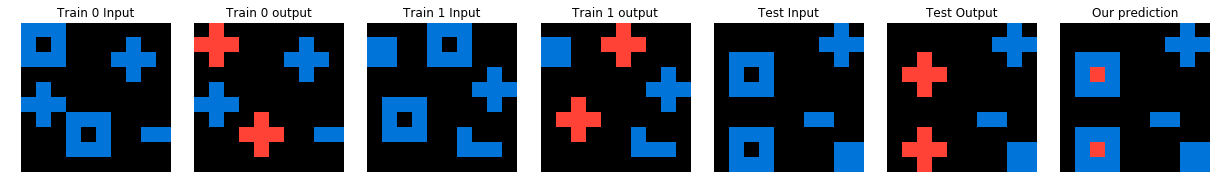

^^^^^^^^^^^^^^^^^^^
178
solved


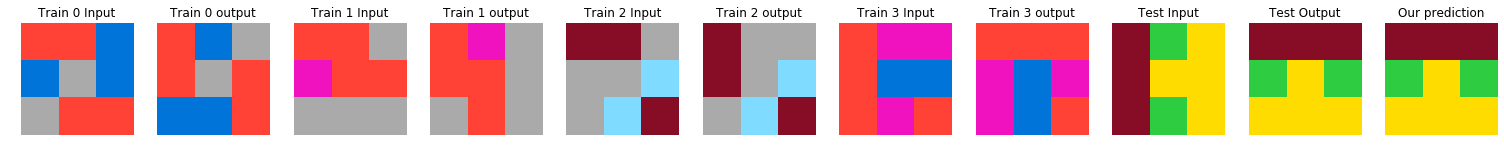

^^^^^^^^^^^^^^^^^^^
186
solved


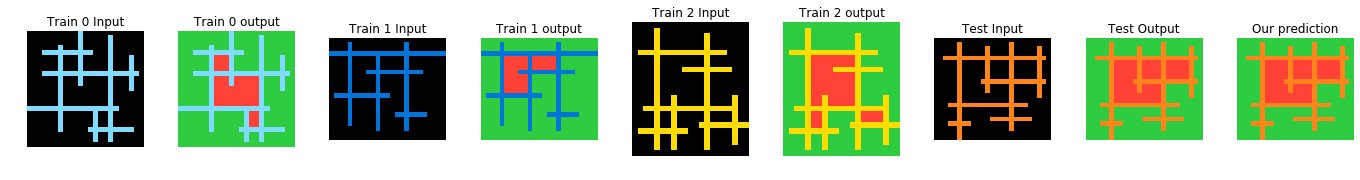

^^^^^^^^^^^^^^^^^^^
203
partially solved


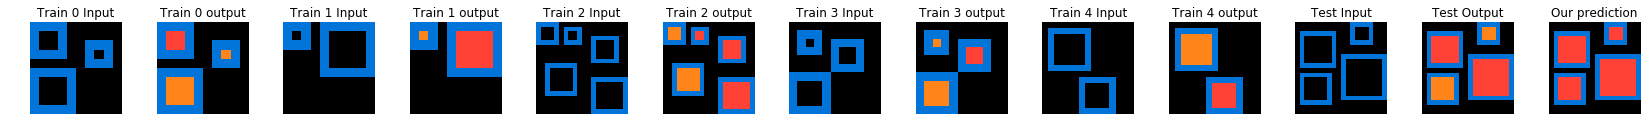

^^^^^^^^^^^^^^^^^^^
240
solved


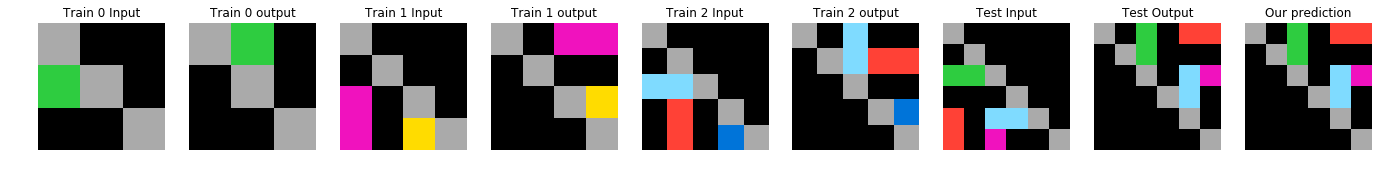

^^^^^^^^^^^^^^^^^^^
250
solved


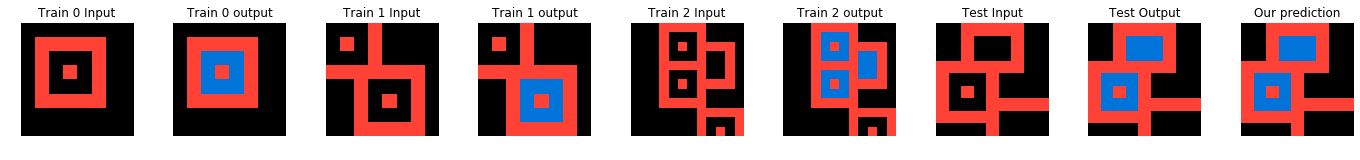

^^^^^^^^^^^^^^^^^^^
266
solved


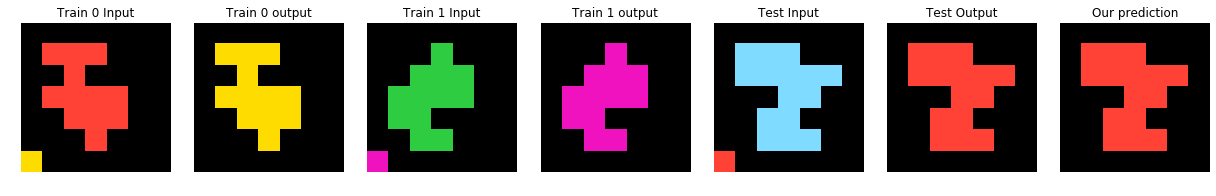

^^^^^^^^^^^^^^^^^^^
293
solved


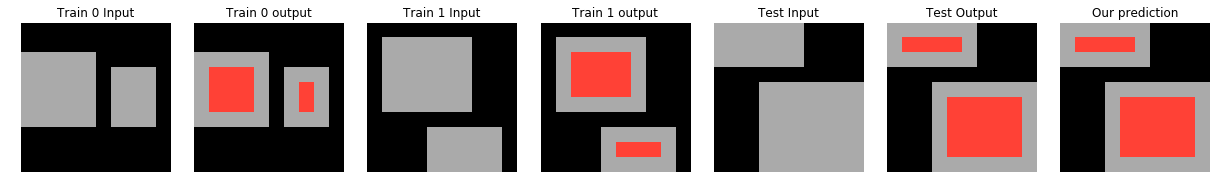

^^^^^^^^^^^^^^^^^^^
337
solved


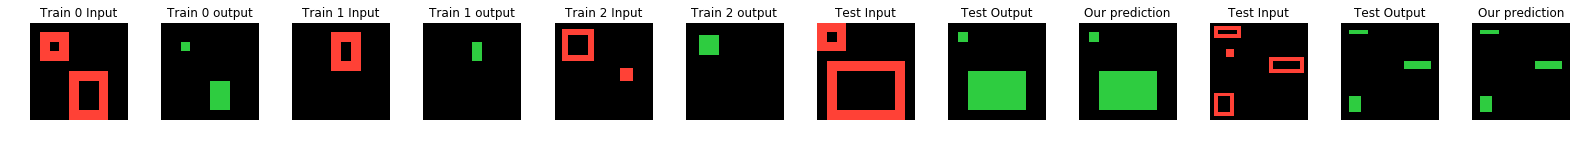

^^^^^^^^^^^^^^^^^^^
345
solved


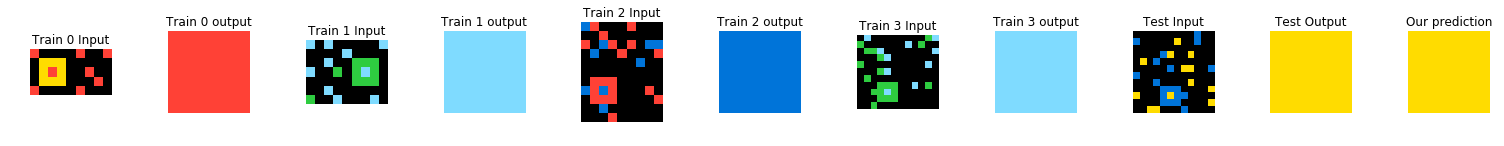

^^^^^^^^^^^^^^^^^^^
366
partially solved


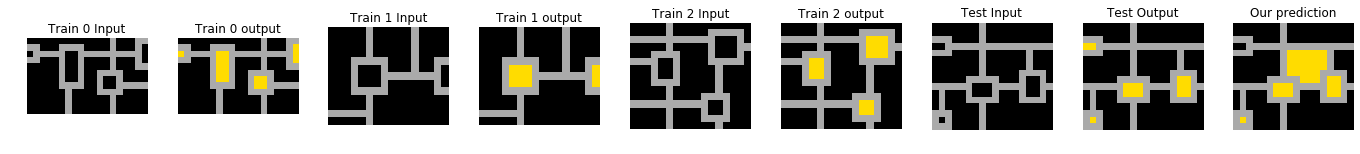

^^^^^^^^^^^^^^^^^^^
379
solved


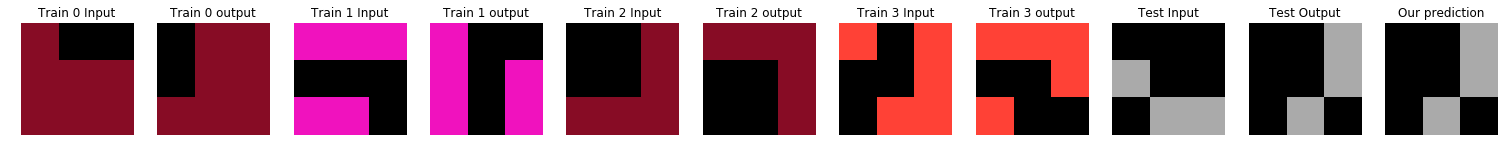

^^^^^^^^^^^^^^^^^^^
400


In [4]:
#today_analysis_05292020 = load_serialized('assets/today_analysis_05292020')
today_analysis_05292020 = []
for n in range(len(tt)):
    #print(n)
    this_task = TaskManager(tt[n])
    today_analysis_05292020.append(this_task)
    if this_task.inductiveV02.solved == 'solved' or this_task.inductiveV02.solved == 'partially solved':
        print(n)
        print(this_task.inductiveV02.solved)
        plot_task_eval(tt[n], this_task.inductiveV02.testpreds)
        print('^^^^^^^^^^^^^^^^^^^')
serialize(today_analysis_05292020, 'assets/today_analysis_05292020')
print(len(today_analysis_05292020))

In [49]:
len(today_analysis_05292020)

400

In [5]:
currently_solved = 0
solved_indices_for_the_day = []
for n in range(len(today_analysis_05292020)):
    if today_analysis_05292020[n].inductiveV02.solved == 'solved':
        #print(n)
        #print(today_analysis_05292020[n].inductiveV02.mechanisms)
        #plot_task_eval(tt[n], today_analysis_05292020[n].inductiveV02.testpreds)
        currently_solved += 1
        solved_indices_for_the_day.append(n)
serialize(solved_indices_for_the_day, 'solved_indices_for_the_day.pkl')
print(currently_solved, ', ', round((currently_solved/400)*100, 3), '%', solved_indices_for_the_day)

# 16 ,  4.0 % [1, 86, 97, 119, 139, 149, 154, 178, 186, 240, 250, 266, 293, 337, 345, 379]%

16 ,  4.0 % [1, 86, 97, 119, 139, 149, 154, 178, 186, 240, 250, 266, 293, 337, 345, 379]


In [6]:
partially_solved = 0
for n in range(len(today_analysis_05292020)):
    if today_analysis_05292020[n].inductiveV02.solved == 'partially solved':
        #print(n)
        #print(today_analysis_05292020[n].inductiveV02.mechanisms)
        #plot_task_eval(tt[n], today_analysis_05292020[n].inductiveV02.testpreds)
        partially_solved += 1
print(partially_solved, ', ', round((partially_solved/400)*100, 3), '%')
# 9 ,  2.25 % (tightened), 26 ,  6.5 % (untightned)

9 ,  2.25 %


In [56]:
def list_comparator(l1, l2):
    if len(l1) == len(l2):
        if all([x > y for x, y in zip(l1, l2)]):
            return '>'
        elif all([x < y for x, y in zip(l1, l2)]):
            return '<'
        elif all([x == y for x, y in zip(l1, l2)]):
            return '=='
        else:
            return None
    else:
        return None

In [57]:
def list_modulo(l1, l2):
    if len(l1) == len(l2):
        if all([x % y == 0 or y % x == 0 for x, y in zip(l1, l2)]):
            return True
        else:
            return False
    else:
        return False

In [105]:
# this is a terminal decision taken after a series of previous decisions
def get_int_div(l1, l2):
        return [y / x for x, y in zip(l1, l2)]

In [139]:
def modify_dimensiosn(dimensions_list, multi_factor_list):
    dimensions_list = deepcopy(dimensions_list)
    if len(dimensions_list[0]) == len(multi_factor_list):
        for n in range(len(dimensions_list)):
            dimensions_list[n] = [int(x * y) for x, y in zip(dimensions_list[n], multi_factor_list)]
        return dimensions_list
    else:
        return None

In [251]:
# cognizant dimensionality assessment
# This function returns the a bolean as of whether it is confident about the dimensions of the test output
# or whether they are not, when they are confident, they also output the predicted dimension, when they are
# not, they output the dimensions of the testinputs
# in_mult_facs and the other outputs are object date memebers
def cognify_dimensions(traininputs, trainoutputs, testinputs):
    ncouples = len(traininputs)
    
    traininput_shapes = [list(x.shape) for x in traininputs]
    trainoutputs_shapes = [list(x.shape) for x in trainoutputs]
    
    testinput_shapes = [list(x.shape) for x in testinputs]
    
    is_sim_in_shapes = all([x.shape == traininputs[0].shape for x in traininputs])
    is_sim_out_shapes = all([x.shape == trainoutputs[0].shape for x in trainoutputs])
    
    is_same_ndim_couple = all([len(x) == len(y) for x, y in zip(traininput_shapes, trainoutputs_shapes)])
    is_same_dim_couple = all([x == y for x, y in zip(traininput_shapes, trainoutputs_shapes)])
   
    
    if is_same_ndim_couple and is_same_dim_couple: # [2, 4] --> [2, 4]
        return True, [list(x.shape) for x in testinputs]  # base case, we return the same shape of inputs
    elif is_same_ndim_couple and not is_same_dim_couple: # [2, 4] --> [4, 8] , [2, 4] --> [4, 5], [2, 4] --> [2, 1], [2, 4] --> [1, 4]
        what_relation = [list_comparator(x, y) for x, y in zip(traininput_shapes, trainoutputs_shapes)]
        if all([x == what_relation[0] for x in what_relation]) and what_relation[0] != None:
            if what_relation[0] == '>' or what_relation[0] == '<':
                unidirctional = all([list_modulo(x, y) for x, y in zip(traininput_shapes, trainoutputs_shapes)])
                in_mult_facs = [get_int_div(x, y) for x, y in zip(traininput_shapes, trainoutputs_shapes)]
                is_sim_int_div = all([x == in_mult_facs[0] for x in in_mult_facs])
                if unidirctional and is_sim_int_div:
                    return True, [tuple(x) for x in modify_dimensiosn(testinput_shapes, in_mult_facs[0])]
                elif unidirctional and not is_sim_int_div:
                    if is_sim_out_shapes:
                        return True, [tuple(trainoutputs_shapes[0])] * len(testinputs)
                    else:
                        if all([x[0] == x[1] for x in in_mult_facs]):
                            return True, in_mult_facs                    
    return False, [tuple(x) for x in testinput_shapes]
    

In [219]:
def is_list_of_list(this_list):
    if len(this_list) > 0 and len(this_list[0]) > 0:
        return type(this_list) == list and type(this_list[0]) == list
    else:
        return False

In [233]:
print(np.all(np.repeat(np.repeat(this_task.traininputs[0], result[1][0][0], 0), result[1][0][1], 1) == this_task.trainoutputs[0]))
print(np.all(this_task.trainoutputs[0][::int(result[1][0][0]),::int(result[1][0][1])] == this_task.traininputs[0]))

True
True


80


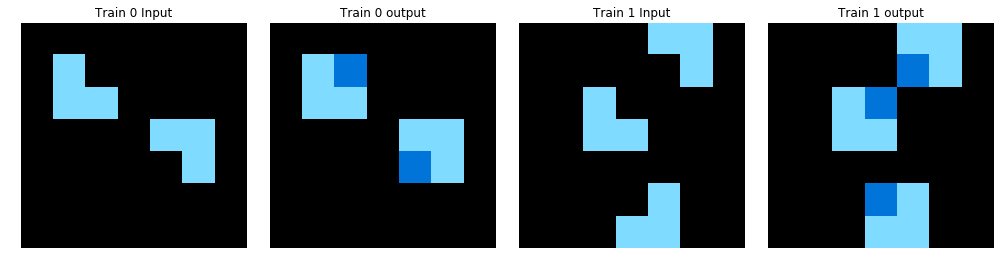

[[7, 7]]
94


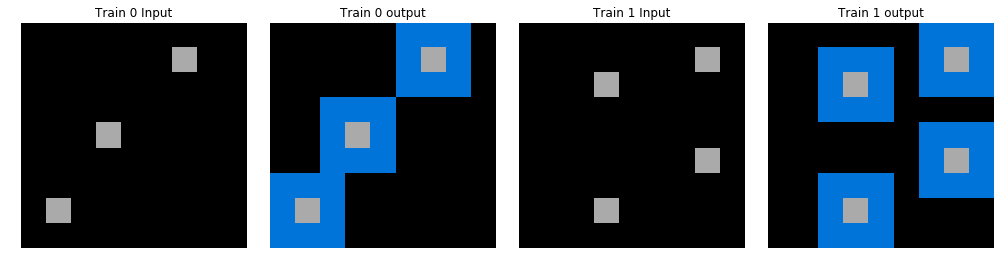

[[9, 9]]
138


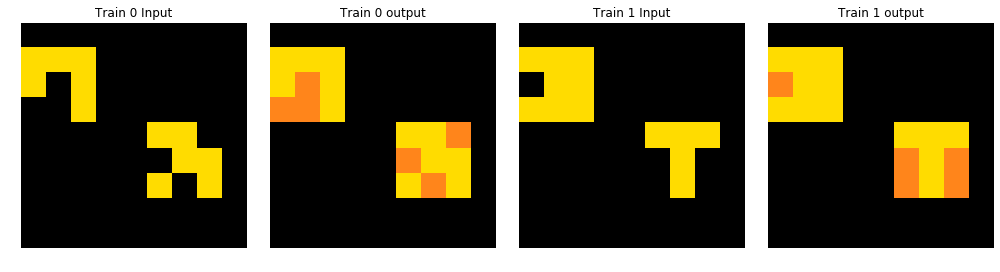

[[9, 9]]
254


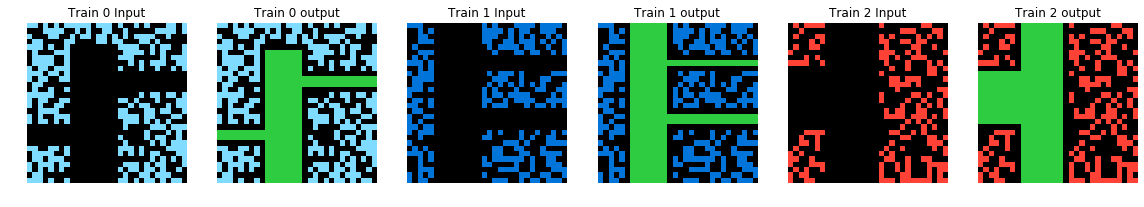

[[30, 30]]
257


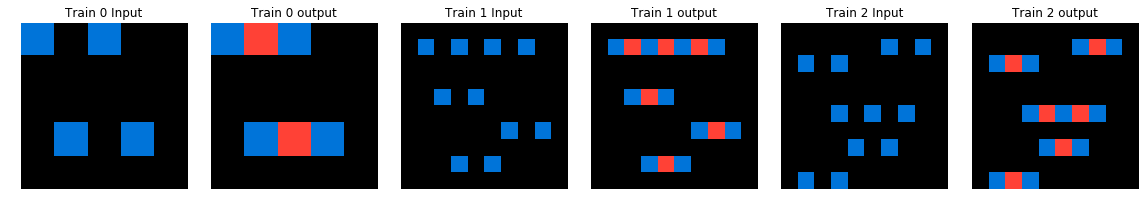

[[10, 10]]
277


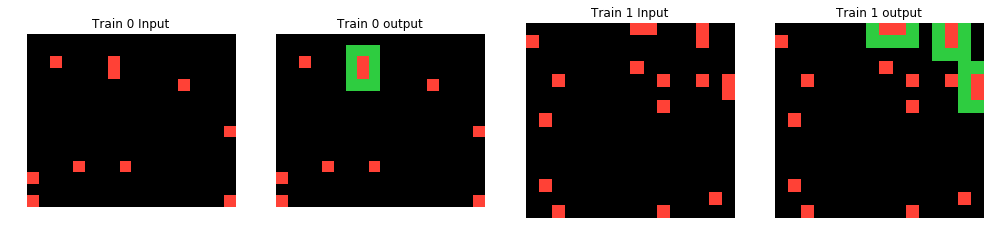

[[17, 16]]


In [258]:
# 222, 268, 288, 306 were detected by the dimension cognifier. 
# It is obvious that we also have the opportunity to merge cases 290 and 345 as captured versiosn into the mix
# there appear to be a global space of how things can correlate, for example, color of captured nonbg or color
# of nonbg surrounding captured bg or another captured nonbg, now add the dimensionality of the size
# of the captured cells, I think the space is becoming more obvious, whatever, these are permutation spaces
# Another example, noe we can see why we struggled with 345, we didn't dissect the problem into a dimensionality
# decision followed by a decision at every point in the output array either starting from testinput if we have same dim
# or starting from an np.zeros((decided_dim)). Now we learnt that np.repeat and slicing can be used to infer 
# conclusions about creation, expansion, contraction, stuff like that. Now, both the dimensions and the captured
# modules are aching for a combination with neighbours space which will be such a great component in the system.
# Grounding prior knowledge and first principles in regards to neighbours can be applied to sets of
# captured cells and find the rule of the capturing by default.

dim_tasks = [222, 268, 288, 306, 290, 338, 345]
nbh_tasks = [80, 94, 257, 138, 254, 277]
for n in range(len(today_analysis_05292020)):
    this_task = today_analysis_05292020[n]
    result = cognify_dimensions(this_task.traininputs, this_task.trainoutputs, this_task.testinputs)
    if result[0] and n in nbh_tasks: # and is_list_of_list(result[1])
        print(n)
        plot_task(tt[n])
        print(result[1])
        print('======')
        
        

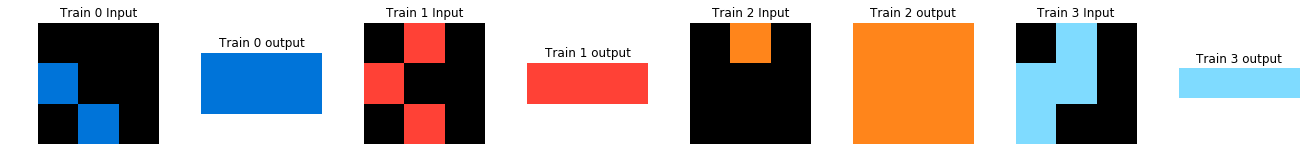

In [168]:
plot_task((tt[338]))

In [257]:
help(nbh)

Help on function <lambda> in module utils:

<lambda> lambda x, i, j



In [ ]:
nbh_tasks = [80, 94, 257, 138, 254, 277]

In [19]:
# size_based_tokenization
# pass assignments coordinates for test input in order to use it to control any direct change, now, you would
# probably be able to open the door for the direct transformations which is supposed to solve certain tasks on 
# its own as a first principle
# We will code any function as long as it points the machine to a first principle. 

275


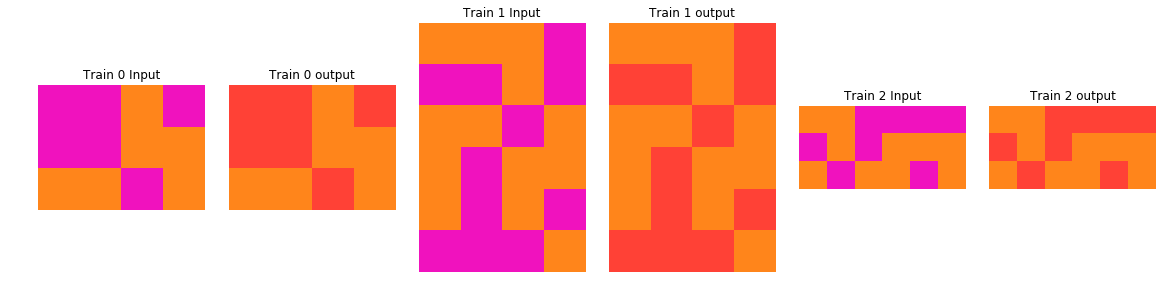

=====
308


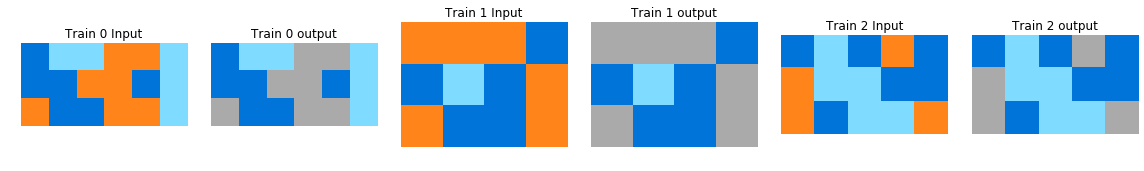

=====
15


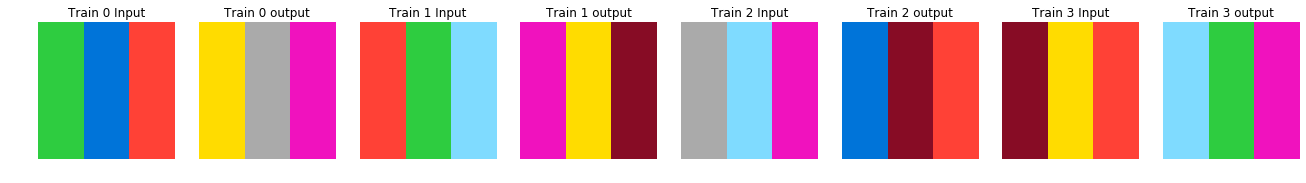

=====
222


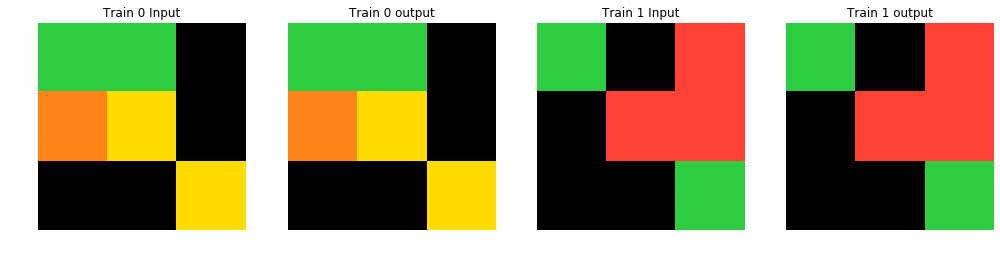

=====
268


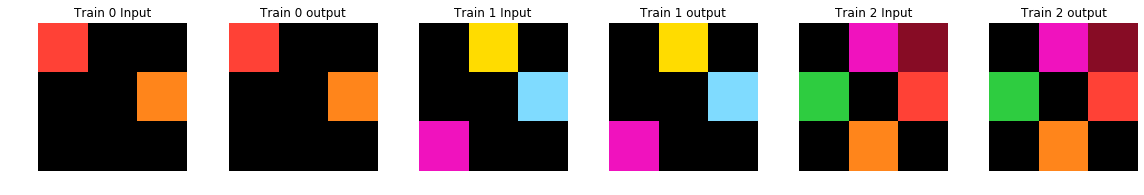

=====
288


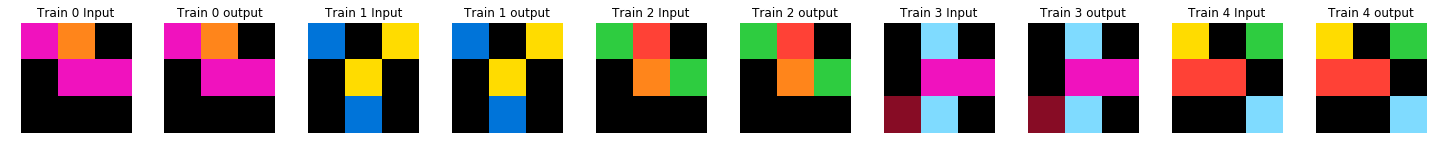

=====
306


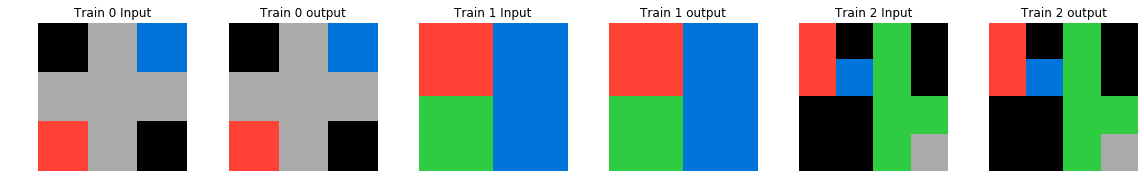

=====
338


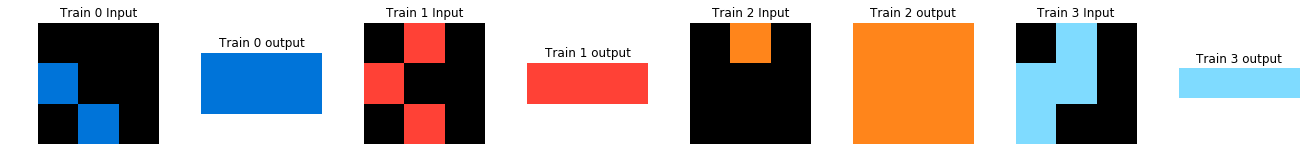

=====
290


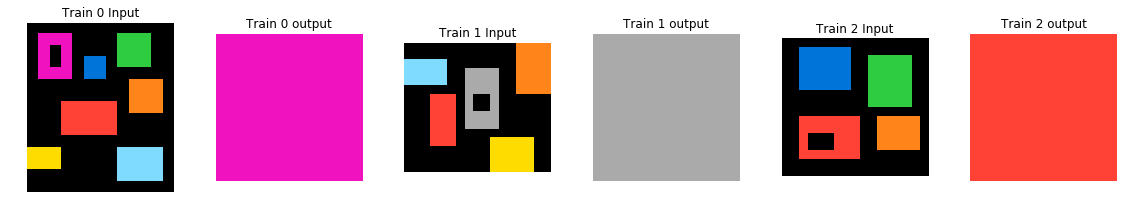

=====
128


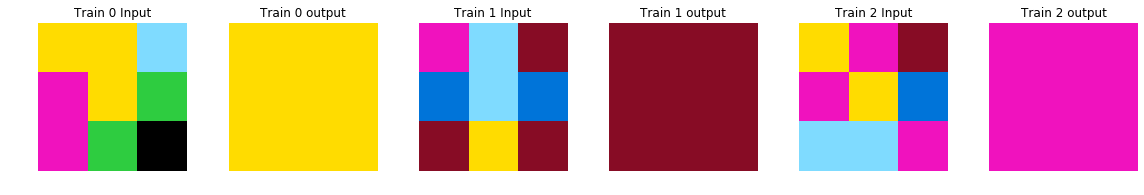

=====
388


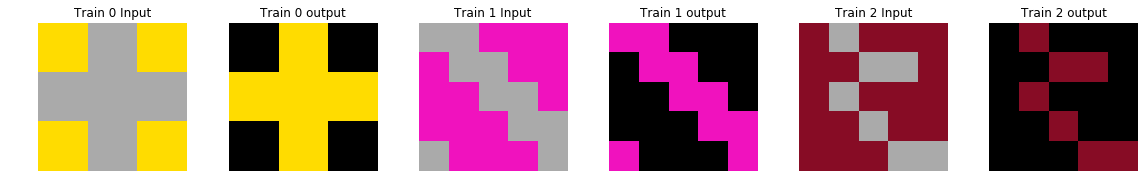

=====
80


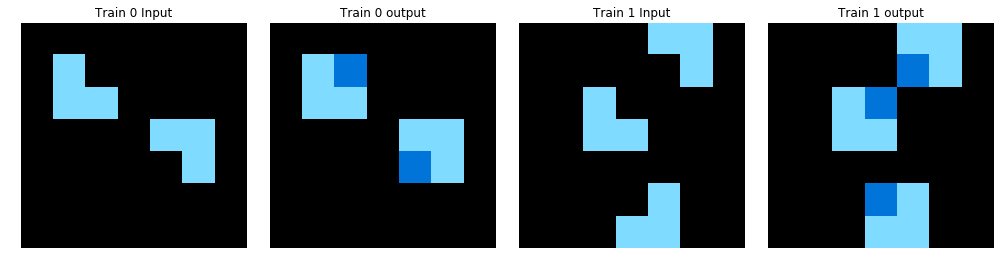

=====
94


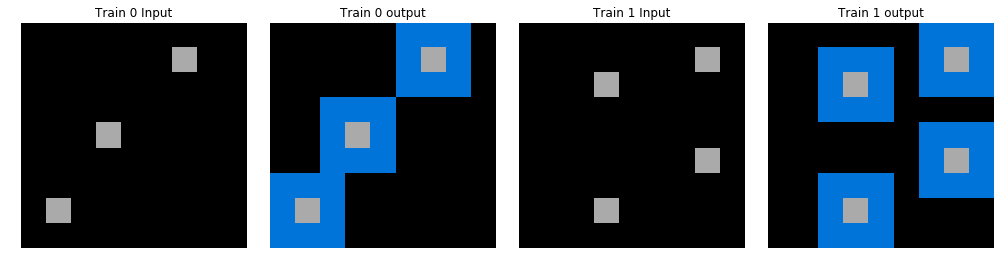

=====
257


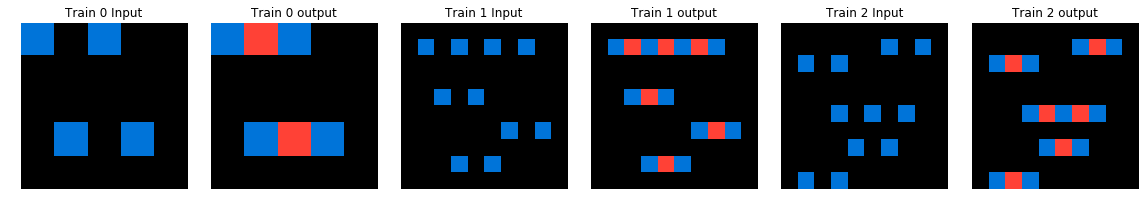

=====
138


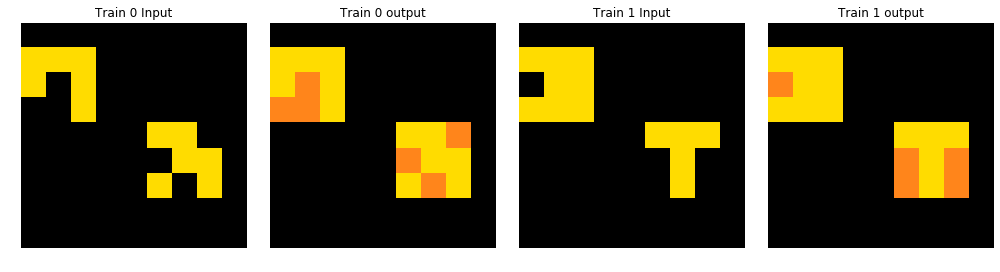

=====
254


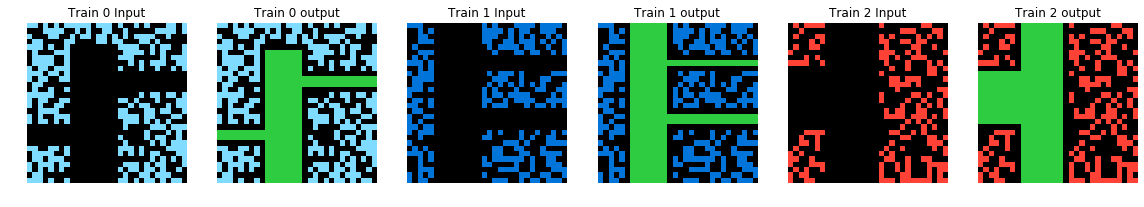

=====
277


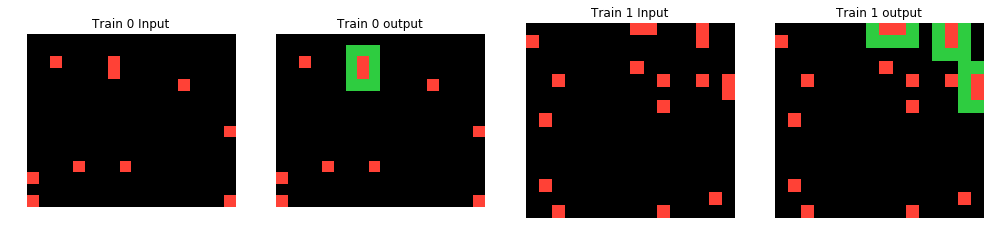

=====
170


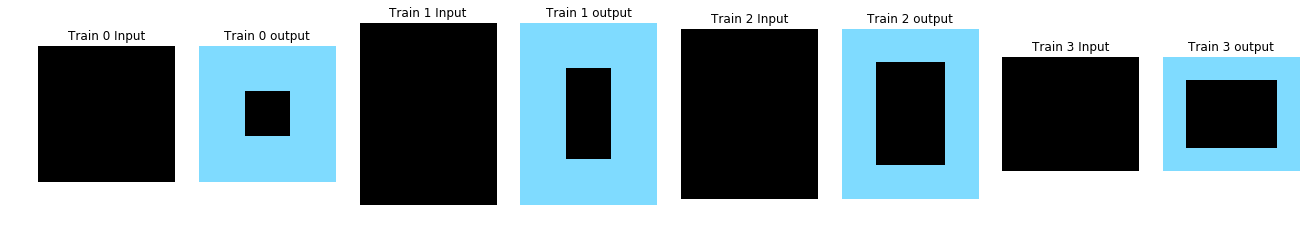

=====
355


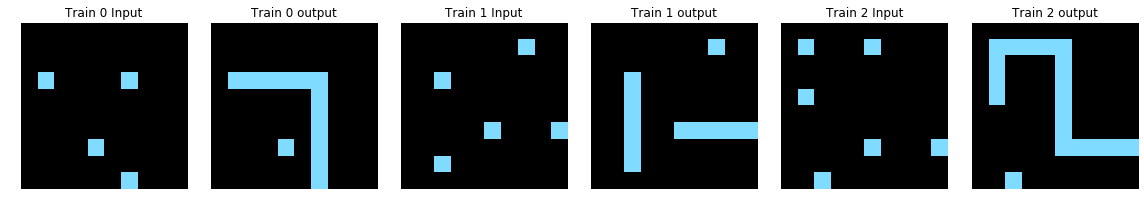

=====
245


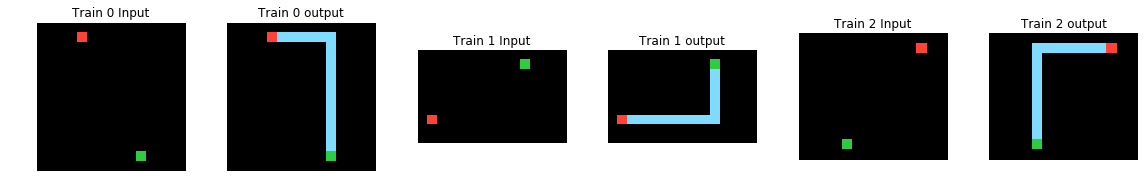

=====
334


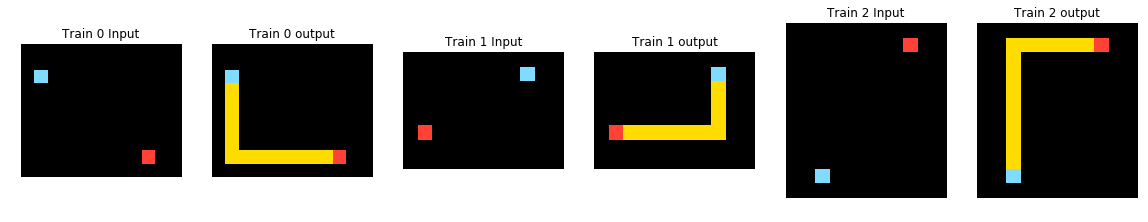

=====
127


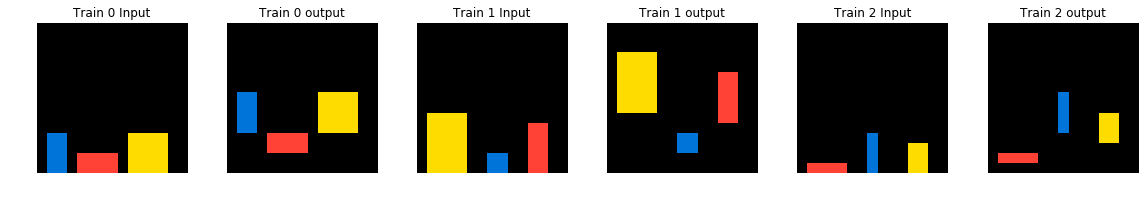

=====
260


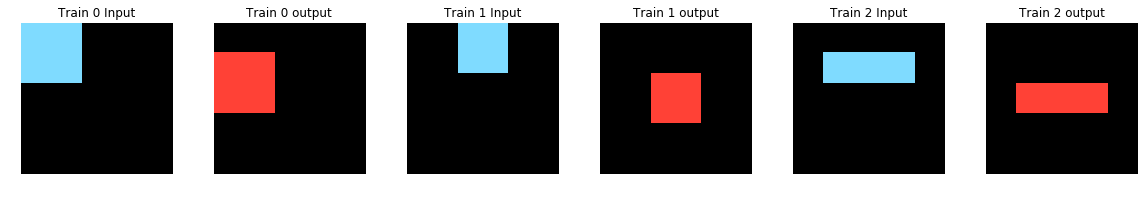

=====
29


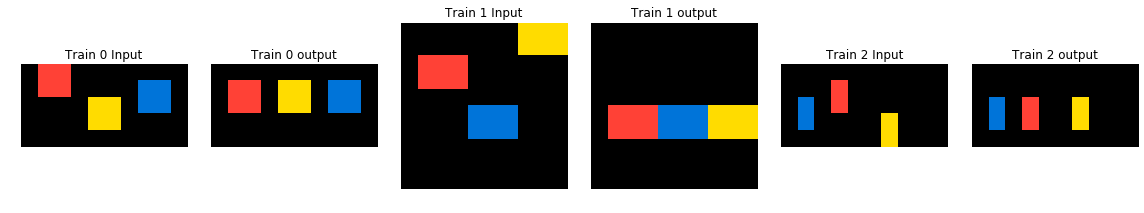

=====
269


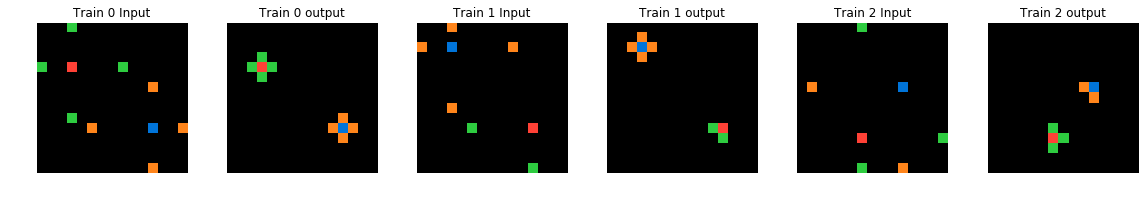

=====
52


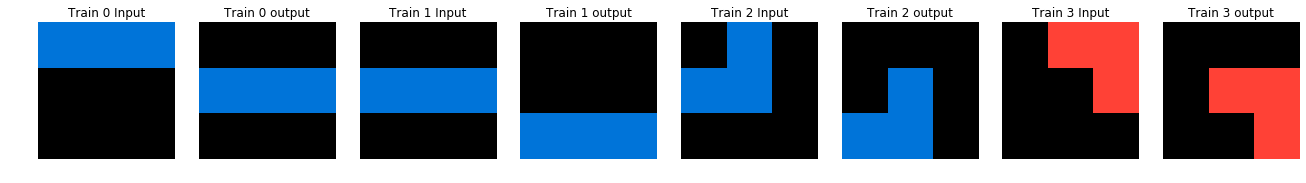

=====
352


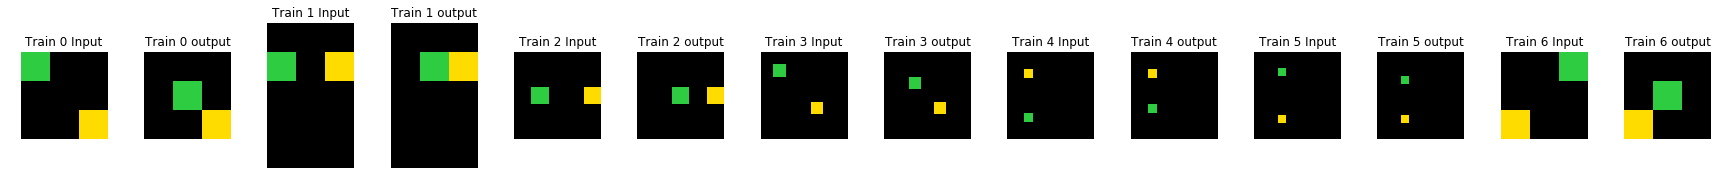

=====
7


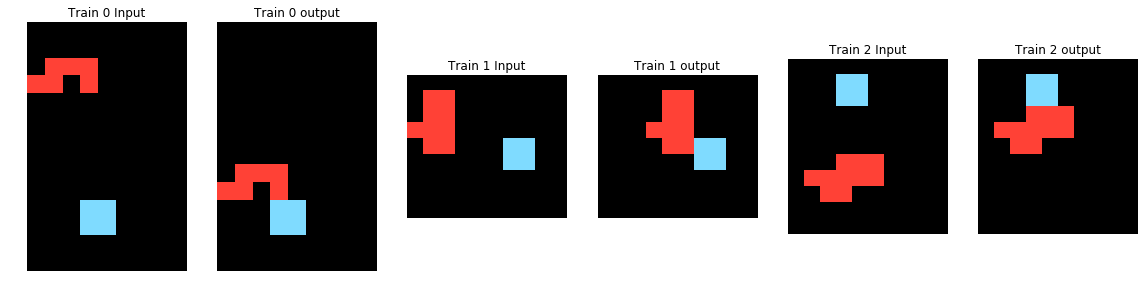

=====
77


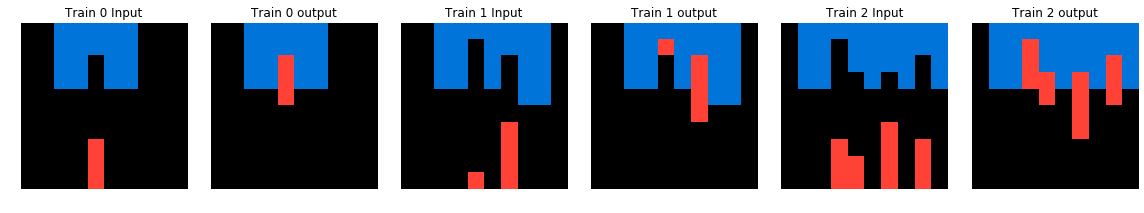

=====
121


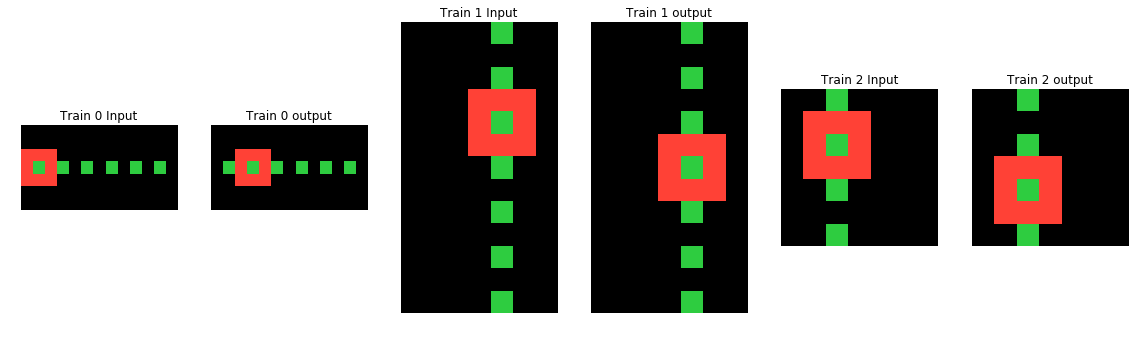

=====
153


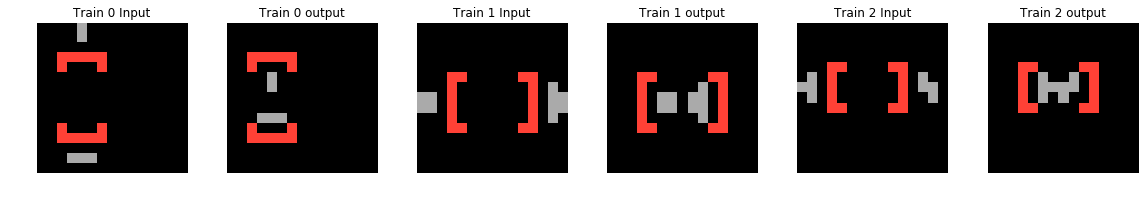

=====
389


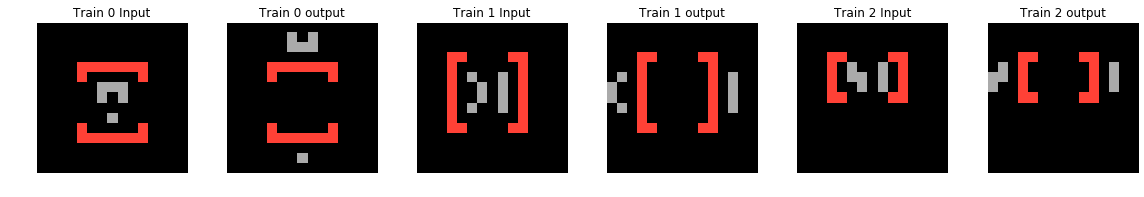

=====
96


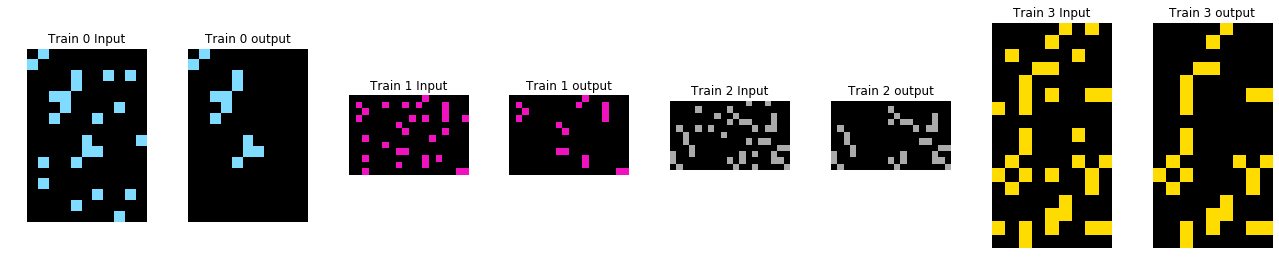

=====
195


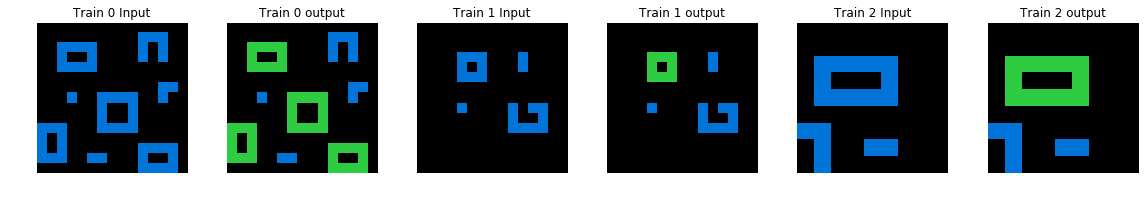

=====
278


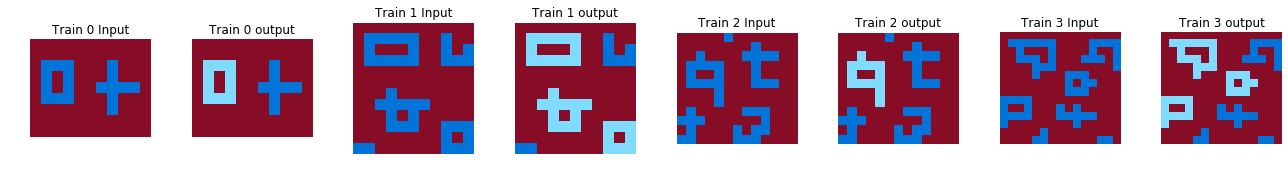

=====
19


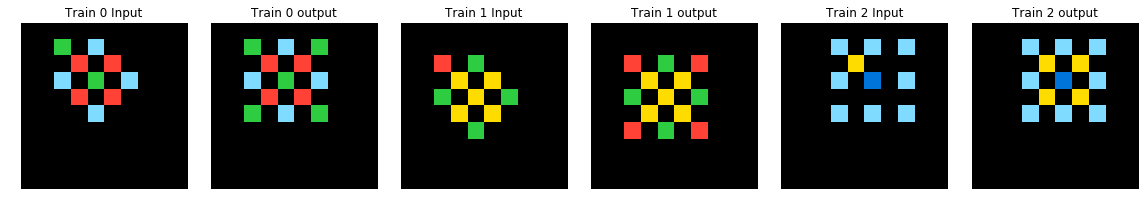

=====
32


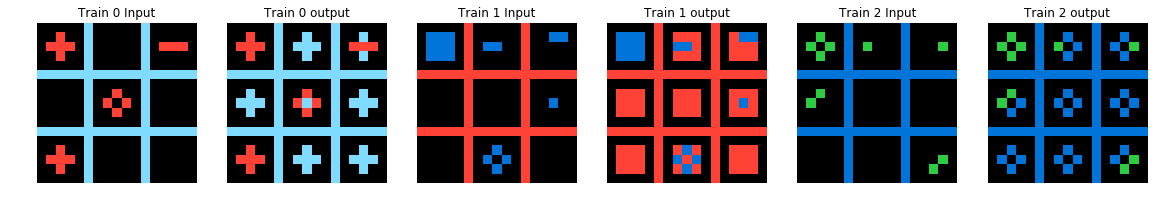

=====
22


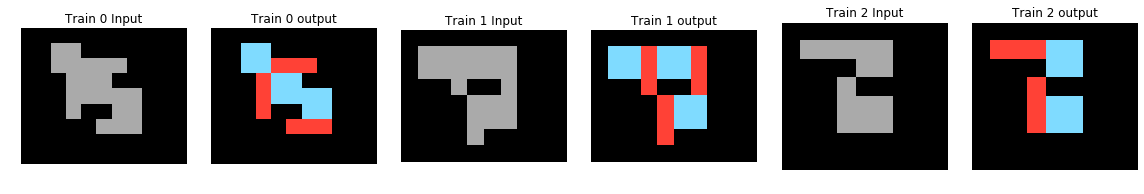

=====
24


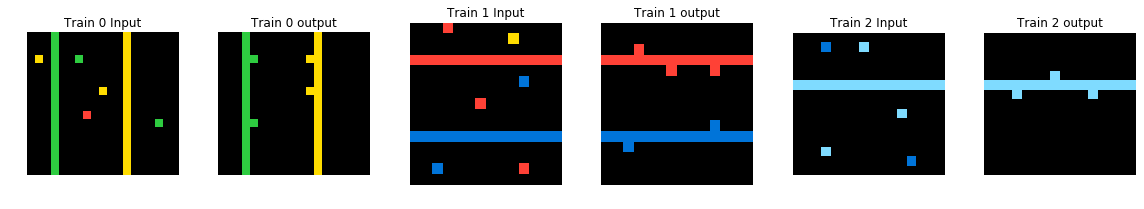

=====
33


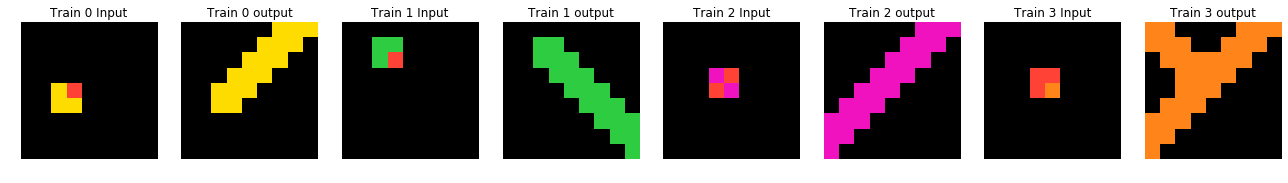

=====
3


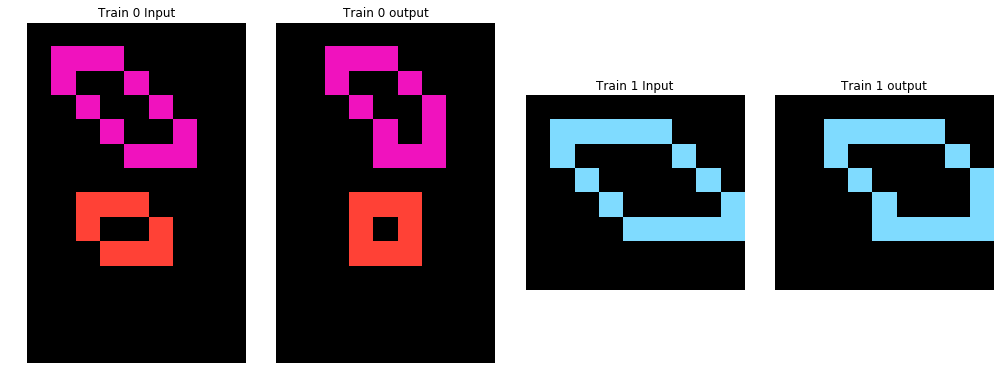

=====
4


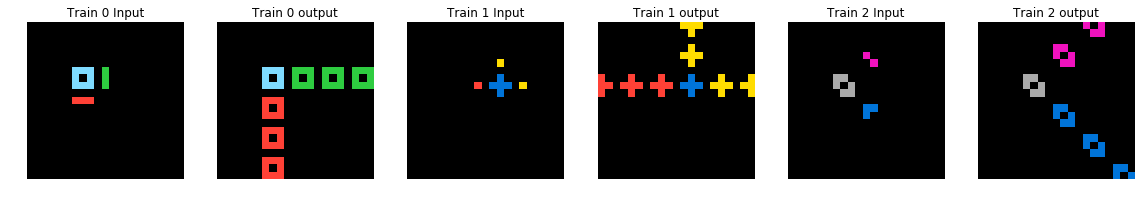

=====
6


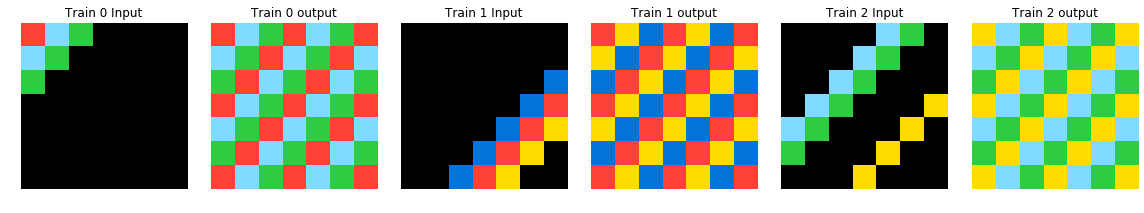

=====
11


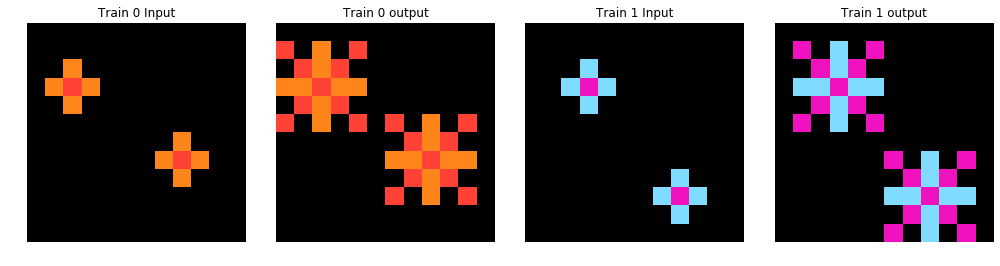

=====
12


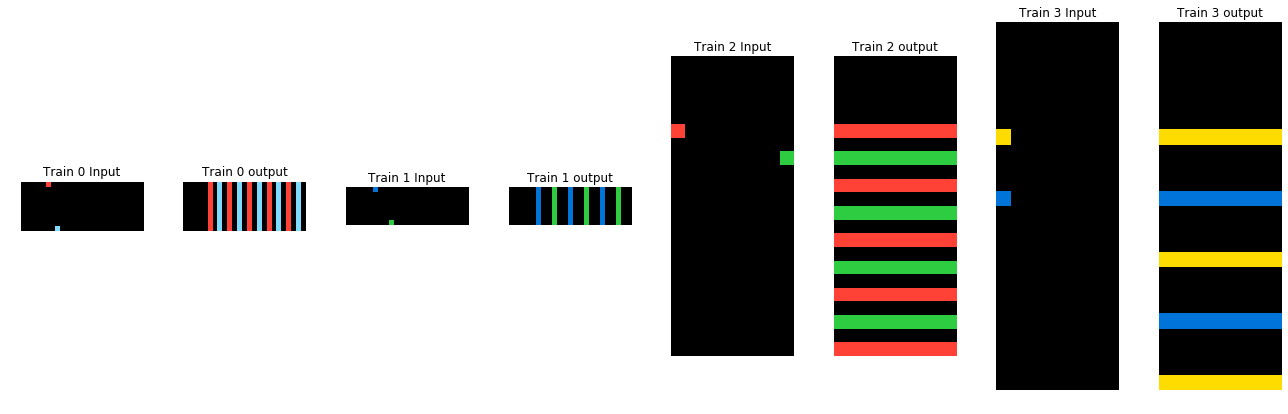

=====
17


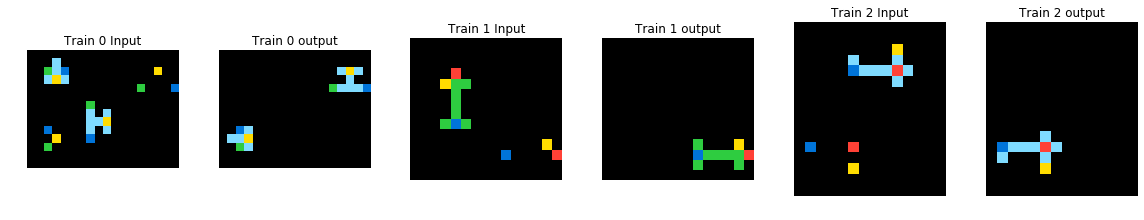

=====
27


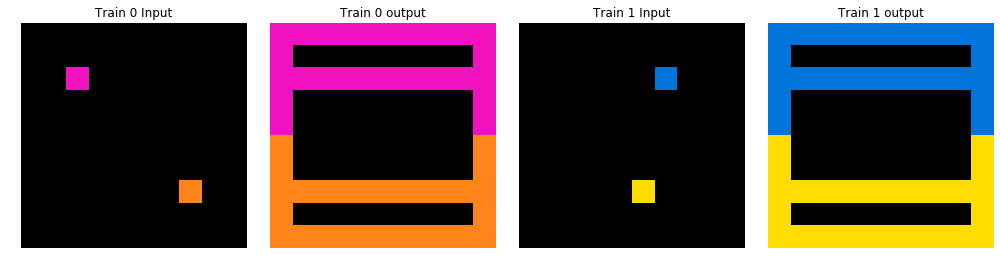

=====
31


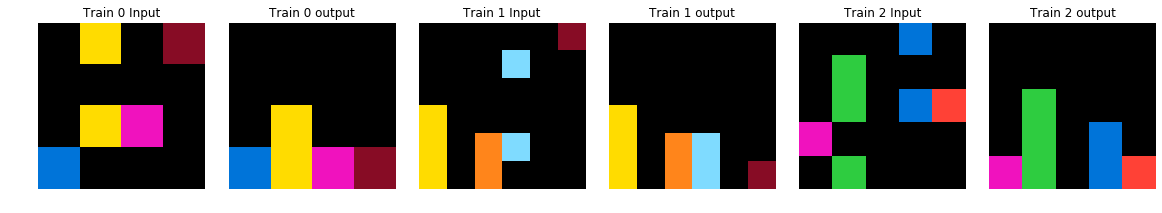

=====
34


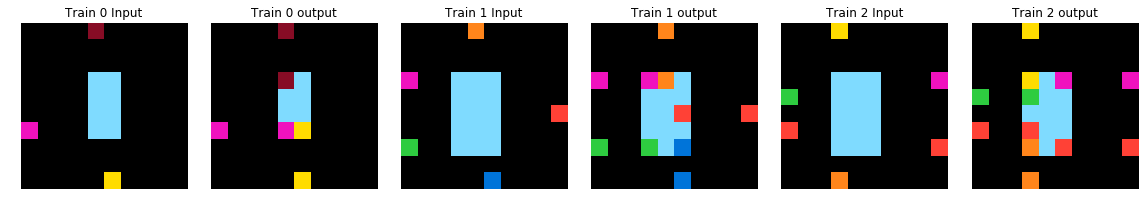

=====
23


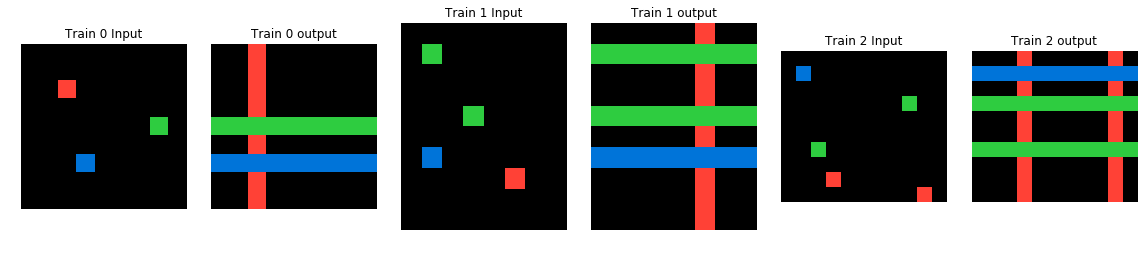

=====


In [10]:
# so basically, we need to add more easy problems with well defined spaces
# spaces are indvidual classes utilized by inductive
# after a few spaces are added, we can estimate a selected set of spaces to test based on the deductive assessment
# and this can be a stochastic experience based system, it just needs us to solve probably at least 300
# out of the training

# There is no magic. The system is well built that in today's milestone, not only we hook up on target cases,
# but we also solve and start guessing on others. The system I will propose will have junctutres or decision
# curves to be either loosened or tightened up such as not applying the direct transformation unless
# the whole objective is satisfiable. These are the cognitive hyperparameters of the system. There are
# so many cognitive hyperparmeters in the current system and these will need to be formulated.

# Objective is based on couples of sets of coordinates representing some sort of abstracted transformation.
# The objective generation strategy seems to be global and is certainly limited in scope. This is why
# all spaces have to lend themselves to tasks with and without objective definition. This generality
# in the system will certainly pay dividends in terms of the space of unseen tasks the system can eventually
# solve deterministically and without one probability sticker.

# spaces:
# 0) dimension changes (222, 268, 288, 306, 338): this must be used by other spaces in order
# 3) capturing: 290 (output a given dimension of the color of the capturing box)

# to decide the output
# 1) outptut the majority in a given dimension 128
# 2) set of one way or two way relationships between values (275-one way, 308-one way, 15-two way)


# 4) sequences of changes: 388
# 5) neighbours, neighbours, neighbours

cur_trial = [275, 308, 15, 222, 268, 288, 306, 338, 290, 128, 388, 80, 94, 257, 138, 254, 277, 170, 355, 245, 334, 127, 260, 29, 269, 52, 352, 7, 77, 121, 153, 389, 96, 195, 278, 19, 32, 22, 24, 33, 3, 4, 6, 11, 12, 17, 27, 31, 34, 23]  
for n in range(len(cur_trial)):
    print(cur_trial[n])
    plot_task(tt[cur_trial[n]])
    print('=====')

In [ ]:
nbh_list = [80, 94, 257, 138, 254, 277]

In [11]:
len(cur_trial)

50

275
-----
308
-----
15
-----
222
-----
268
-----
288
-----
306
-----
338
-----
290
-----
128
-----
388
-----
80
-----
94
-----
257
-----
138
-----
254
-----
277
-----
170
-----
355
-----
245
-----
334
-----
127
-----
260
-----
29
-----
269
unsolved
[[('nonbg0pr', 'bg')], [('nonbg1pr', 'bg')], [('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr')]]
[['nonbg1pr', 'bg', 'direct'], ['nonbg0pr', 'bg', 'direct'], [('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr')]]


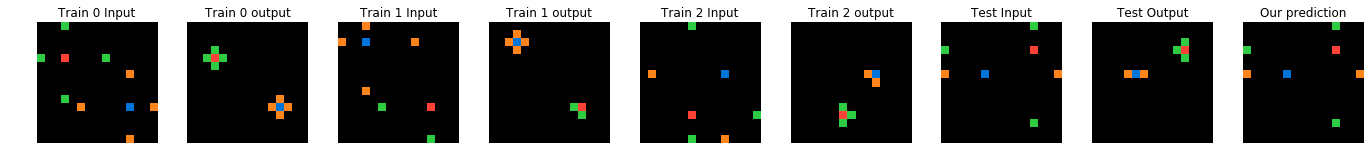

-----
52
-----
352
unsolved
[[('nonbg0pr', 'bg')], [('bg', 'bg'), ('bg', 'nonbg0pr')]]
[['nonbg0pr', 'bg', 'direct'], [('bg', 'bg'), ('bg', 'nonbg0pr')]]


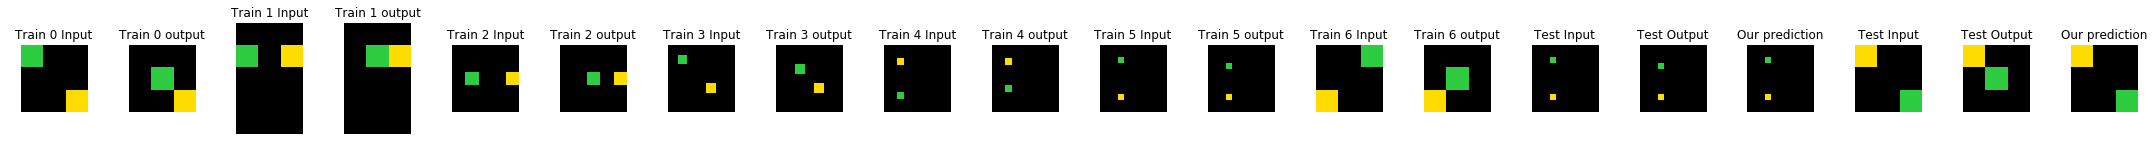

-----
7
unsolved
[[('nonbg0pr', 'bg')], [('bg', 'bg'), ('bg', 'nonbg0pr')]]
[['nonbg0pr', 'bg', 'direct'], [('bg', 'bg'), ('bg', 'nonbg0pr')]]


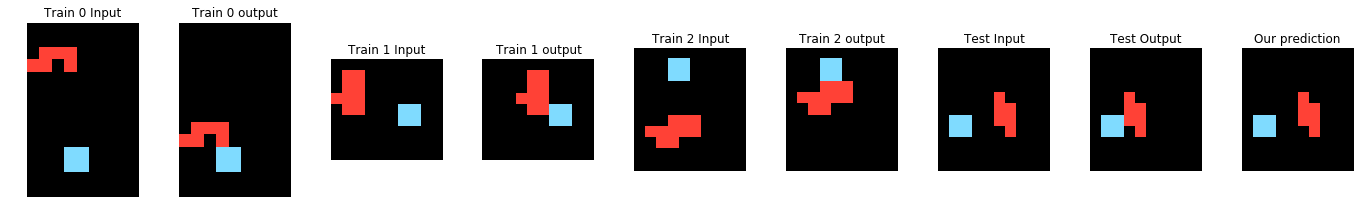

-----
77
-----
121
-----
153
unsolved
[[('nonbg0pr', 'bg')], [('bg', 'bg'), ('bg', 'nonbg0pr')]]
[['nonbg0pr', 'bg', 'direct'], [('bg', 'bg'), ('bg', 'nonbg0pr')]]


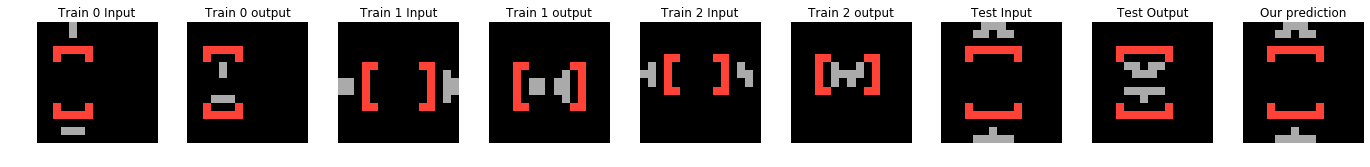

-----
389
unsolved
[[('nonbg0pr', 'bg')], [('bg', 'bg'), ('bg', 'nonbg0pr')]]
[['nonbg0pr', 'bg', 'direct'], [('bg', 'bg'), ('bg', 'nonbg0pr')]]


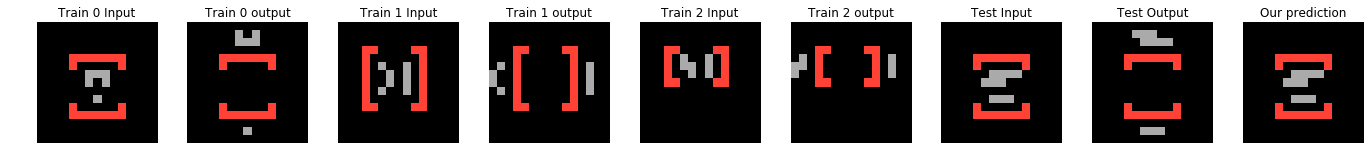

-----
96
-----
195
-----
278
-----
19
unsolved
[[('bg', 'bg'), ('bg', 'nonbg0')]]
[[('bg', 'bg'), ('bg', 'nonbg0'), 'cap_diag', ('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg0'), 'cap_diag', ('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg0'), 'cap_diag', ('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg0'), 'cap_diag', ('bg', 'bg'), ('bg', 'nonbg0')]]


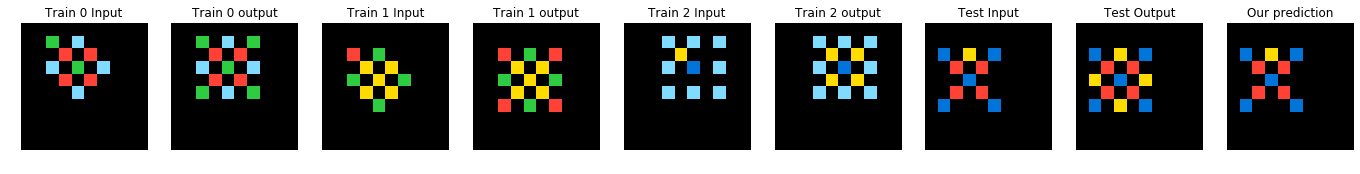

-----
32
-----
22
-----
24
-----
33
unsolved
[[('nonbg0pr', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg1')]]
[['nonbg0pr', 'nonbg1', 'direct'], [('bg', 'bg'), ('bg', 'nonbg1')]]


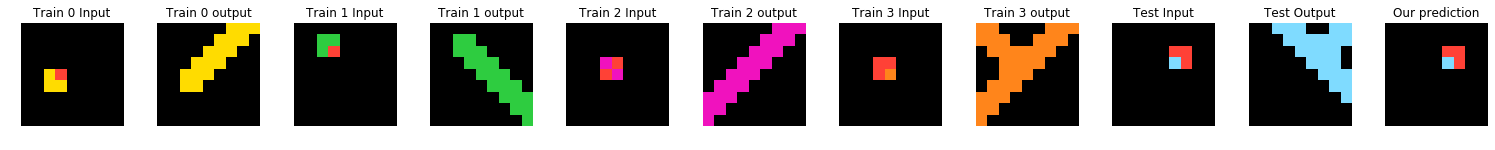

-----
3
-----
4
-----
6
-----
11
-----
12
-----
17
unsolved
[[('nonbg3', 'bg')], [('bg', 'bg'), ('bg', 'nonbg3')], [('nonbg0pr', 'bg'), ('nonbg0pr', 'nonbg0pr')], [('nonbg1pr', 'bg'), ('nonbg1pr', 'nonbg1pr')], [('nonbg2', 'bg'), ('nonbg2', 'nonbg2')]]
[['nonbg3', 'bg', 'direct'], [('bg', 'bg'), ('bg', 'nonbg3')], [('nonbg0pr', 'bg'), ('nonbg0pr', 'nonbg0pr')], [('nonbg1pr', 'bg'), ('nonbg1pr', 'nonbg1pr')], [('nonbg2', 'bg'), ('nonbg2', 'nonbg2'), 'cap_ver_hor', ('nonbg2', 'nonbg2'), ('nonbg2', 'bg')]]


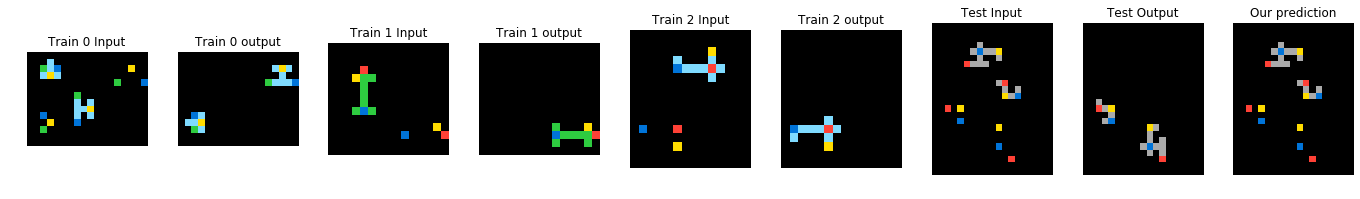

-----
27
-----
31
-----
34
-----
23
-----


In [12]:
for n in range(len(cur_trial)):
    print(cur_trial[n])
    this_task = TaskManager(tt[cur_trial[n]])
    
    if this_task.inductiveV02.objective != this_task.inductiveV02.running_objective:
        print(this_task.inductiveV02.solved)
        print(this_task.inductiveV02.objective)
        print(this_task.inductiveV02.running_objective)
        plot_task_eval(tt[cur_trial[n]], this_task.inductiveV02.cur_test_preds)
        
#     if type(this_task.asssignments_output[0]) == list:
#         for m in range(len(this_task.asssignments_output)):
#             for n in this_task.asssignments_output[m]:
#                 for k, v in n.items():
#                     print(k, ' : ', str([len(l) for l in v]))
#                 print("end of assignment.")
#             print("end of an option :).")
    print('-----')

In [13]:
# 1315 lines code 

In [14]:
# 90 cases out of the 142 tokenized_options[0] to tokenized_options[4] are among the most difficult ones: includes a lot of creation
#
### tokenized_options[0]: "('bg', 'nonbg0')", 56 cases: {"'bg_C', 'bg_S'", "'bg_C', 'bg_S', 'nonbg_S'"}
#                       this case is ideal to understand using reversible rules from output becuase 
#                       when you see a destruction, you should in principle be able to devise a construction using
#                       the opposite first principle
# Task: 1, 250 the easiest way: output: which nonbg cells change an why? == which bg cells change in the input and why?
#                           "'bg_S', 'nonbg_C', 'nonbg_S'"          "'bg_C', 'bg_S', 'nonbg_S'"
#                                    problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2)]

#  Simple flip from bg_C to nonbg_C and in both cases, you must have a way to extract a question such as?
#               what is the difference between 'bg_C' and bg_S' in input and 
#                       the difference between 'nonbg_C' and 'nonbg_S' in output


# Task 80: bg cells with 3 nonbg neighbours is the one to change any other case don't transpire
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (8, 8)]
# Task 94: bg cells with 1 nonbg neighbours is the one to change any other case don't transpire
# Task 257: bg cells with 2 nonbg neighbours is the one to change any other case don't transpire
# Task 138: bg cell with 1, 2, or 3 nonbg neighbours awitch (at least one neigboour)
# Task 254: ongl bg with no neighbours at all change
                # problem_graph: [('bg', 'nonbg0'), (8, 8), ('bg', 'bg'), (1, 1), (2, 2)]
    
# An induction module must offer easy checks such as red versus blue | (can work on output to input but not vice versa)
#                                     captured versus non captured? |  (works on both input and output)
#                                     has neighbours versus has no neighbour? (can work on input to output but can't bring you from output )
#                                     has 3 neighbours versus any other scenario?


# Task 277 is the opposite of finding our what has already been captured, it is the process of finding out
# which one to capture? in this task, you capture any red cells with at least one neighbour?
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2)]

# Task 170 ['bg_C', 'bg_S'] is your base case as far as creation, you have to code it?
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg')]

# Task 355, then 245, 334 is the basic as far as coordinate based line creation is
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2), (3, 3)]
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (8, 8), (2, 2)]
            

#### tokenized_options[1]: "('bg', 'nonbg0'), ('bg', 'nonbg1')", 22 cases: {"'bg_C', 'bg_S', 'nonbg_S'", "'bg_C', 'nonbg_S'"}
# Task 124: "'bg_C', 'bg_S', 'nonbg_S'": captured + capturing (combination we talk about)
            # problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'bg'), (6, 6)]
    
# Others are more difficult creation, machine not there yet I guess
#### tokenized_options[2]: "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2')", 7 cases: {"'bg_C', 'bg_S', 'nonbg_S'", "'bg_C', 'nonbg_S'"}
# more progression of the previous ones, more diversity in creation
#### tokenized_options[3]: "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('bg', 'nonbg3')": 3 cases {"'bg_C', 'bg_S', 'nonbg_S'"}
#### tokenized_options[4]: "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('bg', 'nonbg3'), ('bg', 'nonbg4')": 2 cases {"'bg_C', 'bg_S', 'nonbg_S'"}


# tokenized_options[6]
# Task 127, 260: basic movement: [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg')]
#                           ['bg_C', 'bg_S', 'nonbg_C_bg']
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg'), ('bg', 'bg')]


# tokenized_options[8]
# Task 29, 43, 269: selective movement: [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg')]
#                           ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S'] nonbg_S don't move, it is the anchor as far as position
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), 
#                  ('bg', 'bg'), ('nonbg0', 'nonbg0'), (1, 1), ('nonbg1', 'nonbg1')]
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), 
#                  (7, 7), ('bg', 'bg'), (5, 5), ('nonbg0', 'nonbg0'), (4, 4)]
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), 
#                  ('bg', 'bg'), (2, 2), (1, 1)]

# tokenized_options[10]: 11 case : [('bg', 'nonbg0'), ('nonbg0', 'bg')], ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
# Transitions: 52: most basic movement, just one row down!
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (2, 2)] # wrong, 2 is in fact nonbg0
#              352: green towards yellow!
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (4, 4)]
#             7, 77, 121: movements influneced by coordinate of an attracting object
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (8, 8)]
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (1, 1), ('nonbg0', 'nonbg0')]
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (3, 3)]

#             153 and 389 are mirror images of each others: same problem_graph
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (2, 2)]
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (2, 2)]


# tokenized_options[17]: 2 cases: [('nonbg0', 'bg')],  ['bg_S', 'nonbg_C_bg', 'nonbg_S']
#                        Task 96: nonbg with at least one nonbg neighbours survive
# problem_graph:  [('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (6, 6), (5, 5), (4, 4)] # wrong because 4, 5, 6 are all nonbg0 
#                        Task 192: nonbg with less than two nonbg neghbours disappear
# problem_graph:  [('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (6, 6), (5, 5)] # wrong because 5, 6 are nonbg0
################

# tokenized_options[18]: [('nonbg0', 'bg'), ('nonbg0', 'nonbg1'), ('nonbg0', 'nonbg2')]
#                        ['bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg']
#                         here, max turn to blue and min turn into red and in between vanishes

# tokenized_options[23]: 8 cases, "('nonbg0', 'nonbg1')" ['bg_S', 'nonbg_C_nonbg', 'nonbg_S']
#                       Task 195, 278: only nonbg neighbours of captured bg changes
# problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
# problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]



# tokenized_options[26]: [('nonbg0', 'nonbg1'), ('nonbg0', 'nonbg2'), ('nonbg0', 'nonbg3'), ('nonbg0', 'nonbg4')]
#                        ['bg_S', 'nonbg_C_nonbg']
#                        nonbg0 changes to colors based on the number of cells: 9, 373
#                         

# tokenized_options[27]: [('nonbg0', 'nonbg1'), ('nonbg1', 'bg')]
#                        ['bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg']
#                        nonbg0 ---> nonbg1, nonbg1 --> bg (nonbg1 is just one cell in the corner): 266

 
# Some none tokenized non deductive coder cases:
# This belongs to the 186 untokenized cases:
# 0) one color change: 275, 308: there is a global value map
# 00) case 15: consistent value map changes: global_value_map:  {3: {4}, 1: {5}, 2: {6}, 8: {9}, 5: {1}, 6: {2}, 9: {8}, 4: {3}}
# 000) Flips 86, 139, 149, 154, 178, 379
# 1) for n in [222, 268, 288, 306]: there is a simple relationship between the dimensions of the input and the output
#                                and then you apply this to each individual

# 2) case: 338: different dimensions: you just output a numpy array including the nonbg cells
# 3) case 345: output the captured cell value!
# 4) case 290: output the color of the box with captured bg cells
# 5) case 128: output the most frequent value on a similar dimension
# 6) 202, 297: alternating squares lines
# 7) 388: very very important to systematize a change in color: nonbg0--> nonbg1, nonbg1-->nonbg2
# couple_val_map:  [{4: {0}, 5: {4}}, {5: {6}, 6: {0}}, {9: {0}, 5: {9}}]
# here you have to cognify ahha, you shall go 4 --> 0 then 5 --> 4
# 97: all captured nonbg turn into bg
# 119: all captured nonbg turn into the same nonbg
# 191 is a little bit over the 192 case

# for latter but important:
# extracting a shape: 30, 35, 289, 383
# extract then double: 56
# extract and then change color!/translate/scale!
# extract the smallest rectagle: 48, biggest, one towards the corner!
# extract a quadrant with a different color shape: 64
# extract most frequent shape 78
# spatial effects based on dimension of most colors: 114, 177, 212
# 156: movements

In [15]:
coding_situation = {}
coding_situation[0] = []
coding_situation[1] = []
coding_situation[2] = []


for n in range(len(today_analysis_05292020)):
    this_task = today_analysis_05292020[n]
    same_color_to_token = all(x == this_task.color_to_tokens[0] for x in this_task.color_to_tokens)    
    if type(this_task.problem_graph[0]) == str:
        coding_situation[0].append(n)
    elif type(this_task.problem_graph[0]) == list and same_color_to_token:
        coding_situation[1].append(n)
    else:
        copy_problem_graph = []
        for m in this_task.problem_graph:
            copy_problem_graph.append(tuple(sorted([y for y in m if type(y[0]) == str])))
        copy_problem_graph = list(set(copy_problem_graph))

        if len(copy_problem_graph) == 1:
            coding_situation[1].append(n)
        else:
            coding_situation[2].append(n)
        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))

# 0  :  186
# 1  :  156
# 2  :  58

0  :  186
1  :  156
2  :  58


In [16]:
coding_situation = {}
coding_situation[-1] = []
coding_situation[0] = []
coding_situation[1] = []
coding_situation[2] = []


for n in range(len(today_analysis_05292020)):
    this_task = today_analysis_05292020[n]
    if this_task.objective_status == 'None':
        coding_situation[-1].append(n)
    elif this_task.objective_status == 'irr':
        coding_situation[0].append(n)
    elif this_task.objective_status == 'obd':
        coding_situation[1].append(n)
    elif this_task.objective_status == 'red':
            coding_situation[1].append(n)
    elif this_task.objective_status == 'pred':
            coding_situation[2].append(n)
        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))
# -1  :  186
# 0  :  51
# 1  :  163


-1  :  186
0  :  51
1  :  163
2  :  0


3


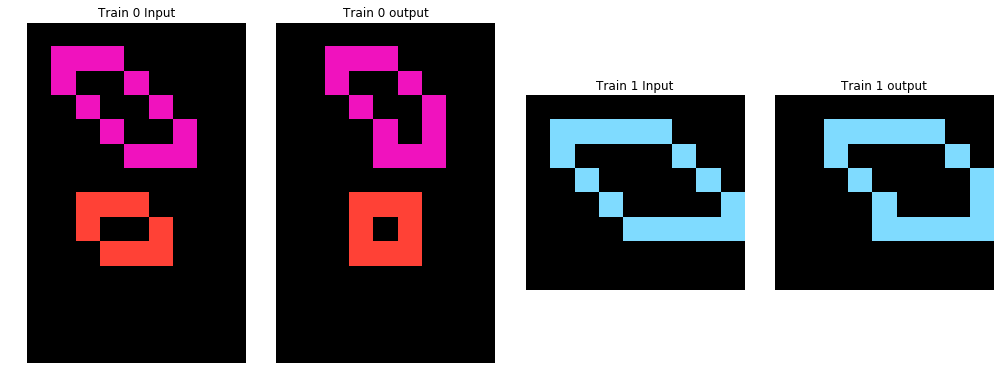

24


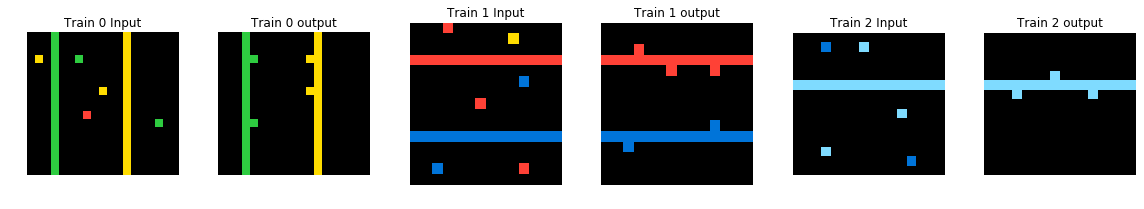

29


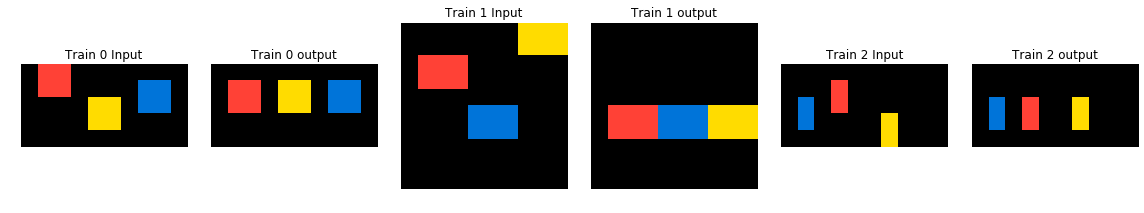

31


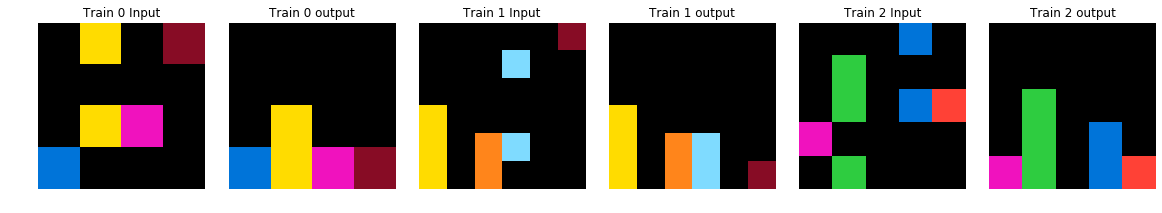

34


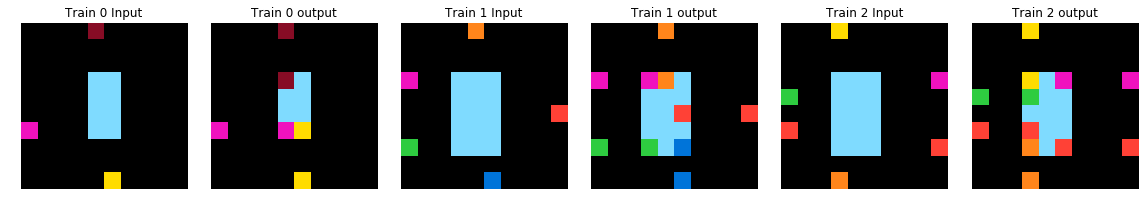

36


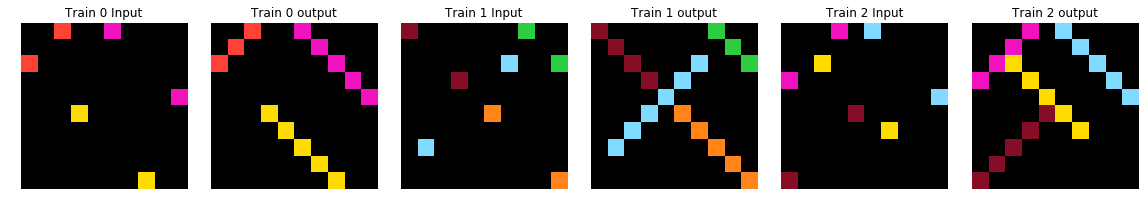

40


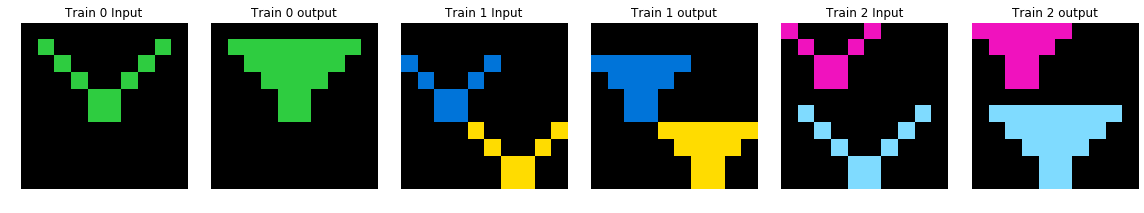

60


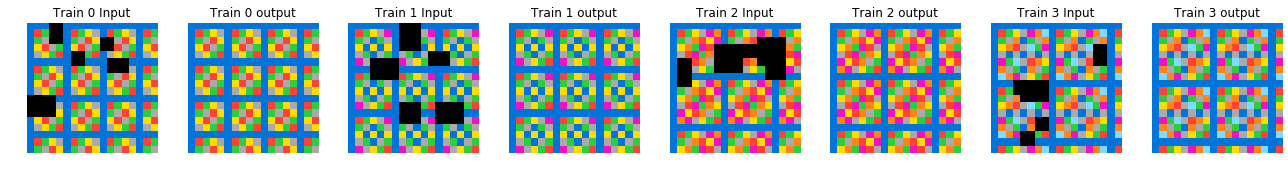

67


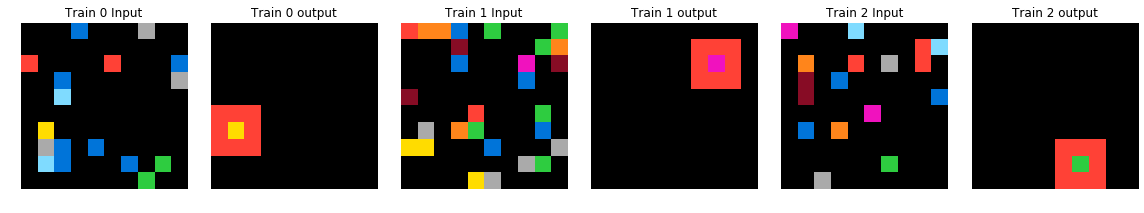

70


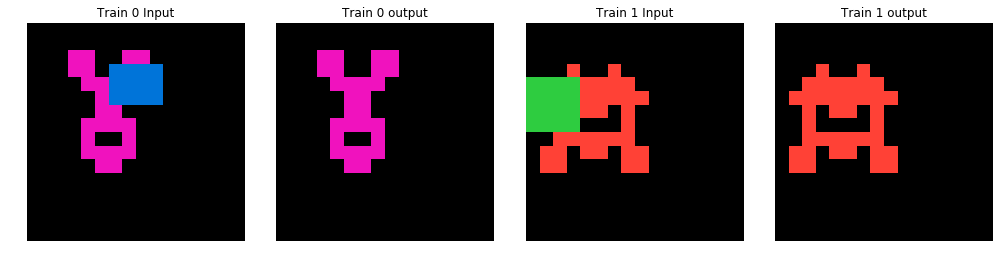

73


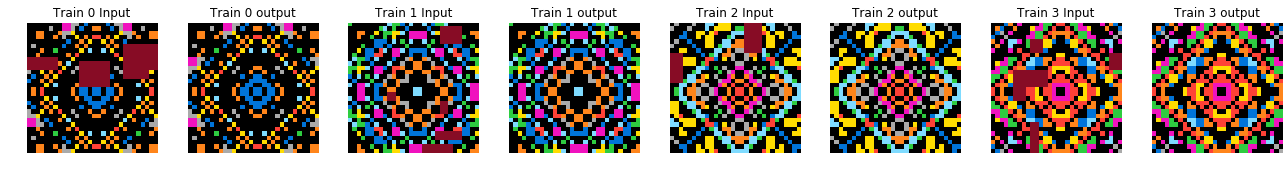

74


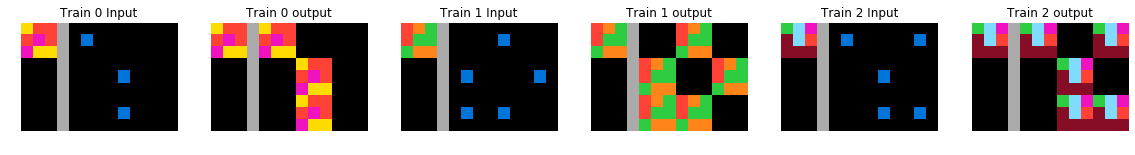

81


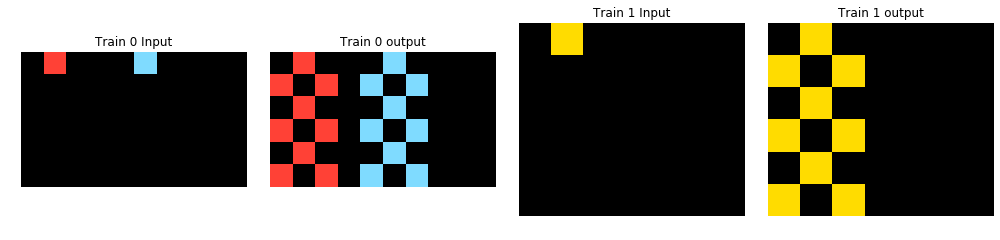

85


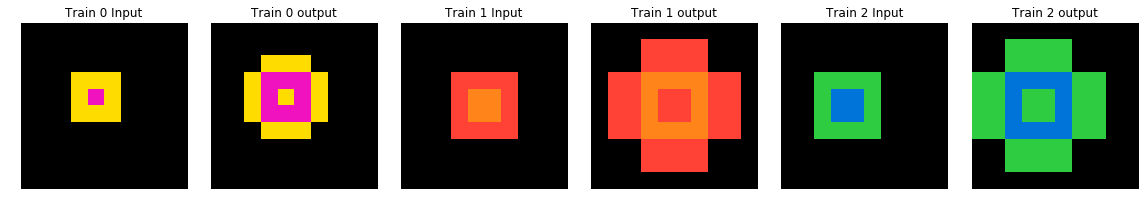

88


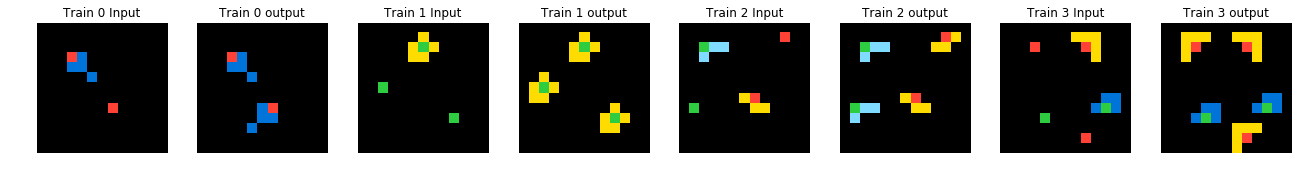

98


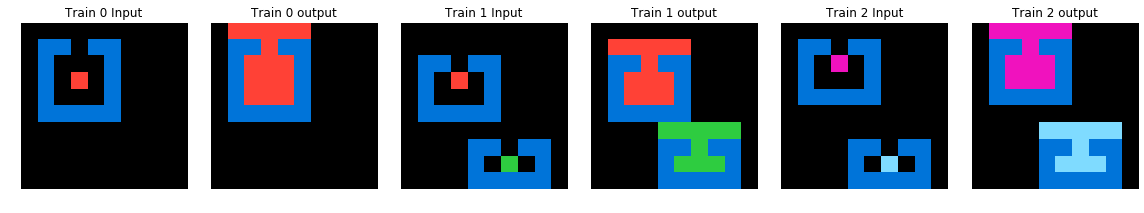

126


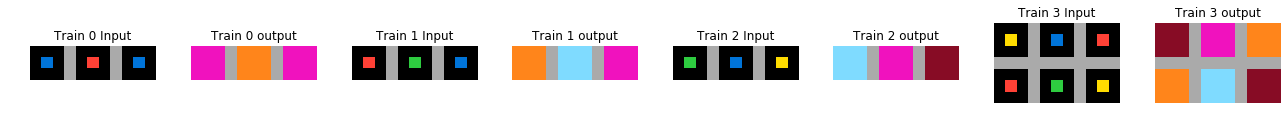

131


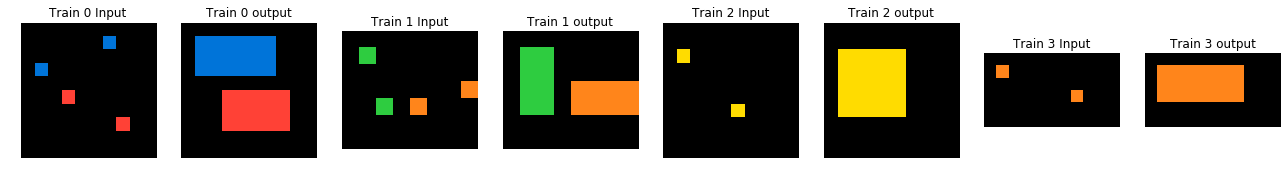

132


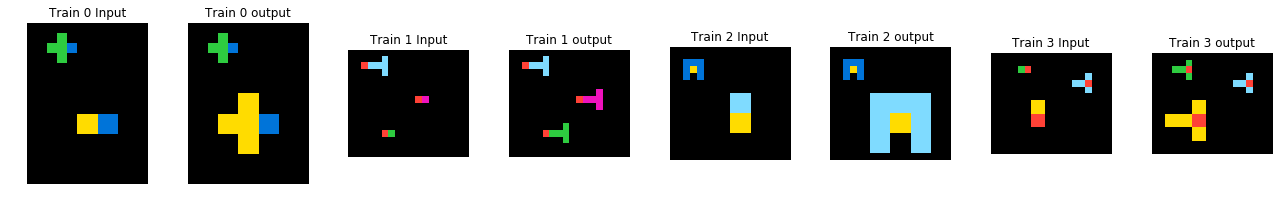

139


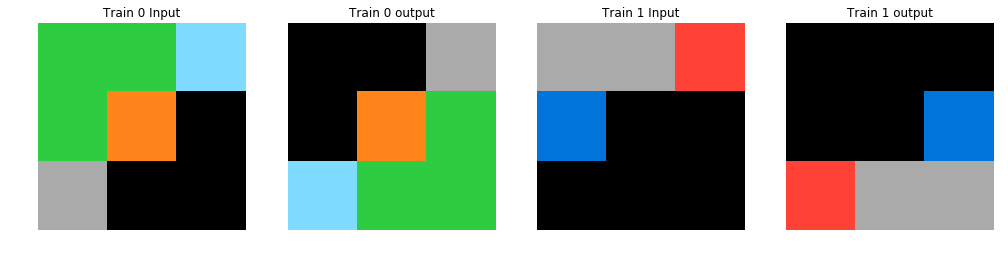

160


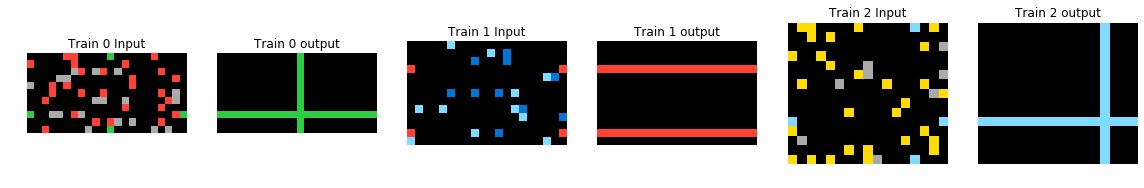

172


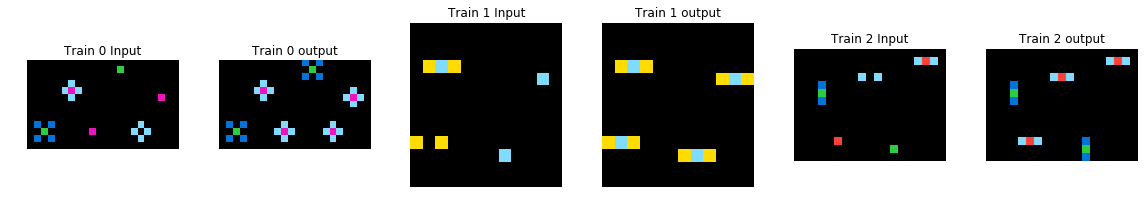

191


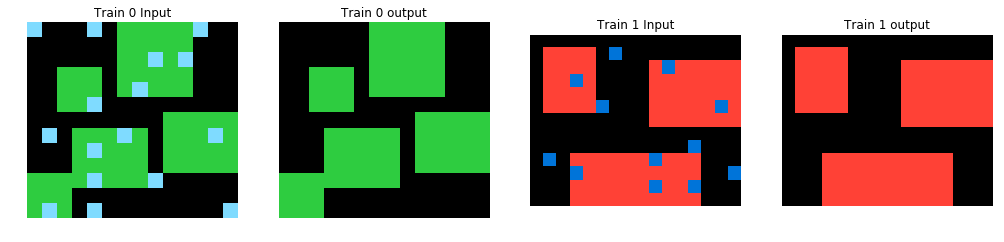

196


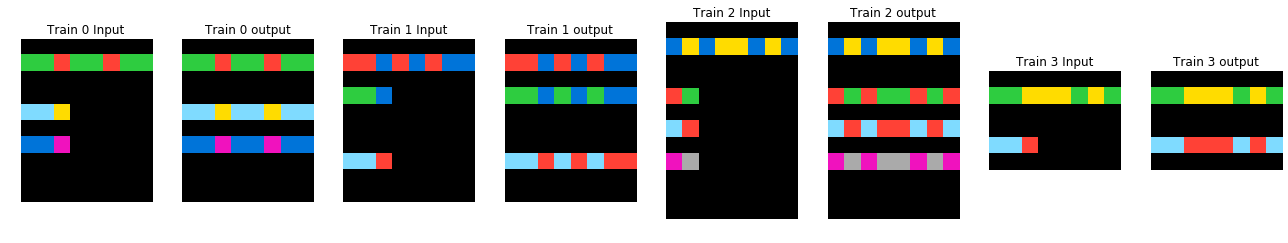

198


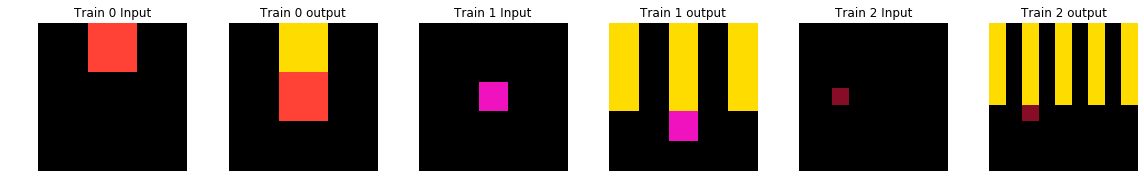

205


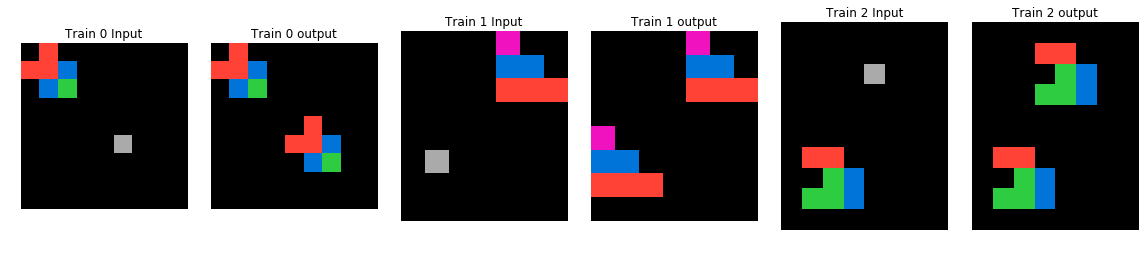

221


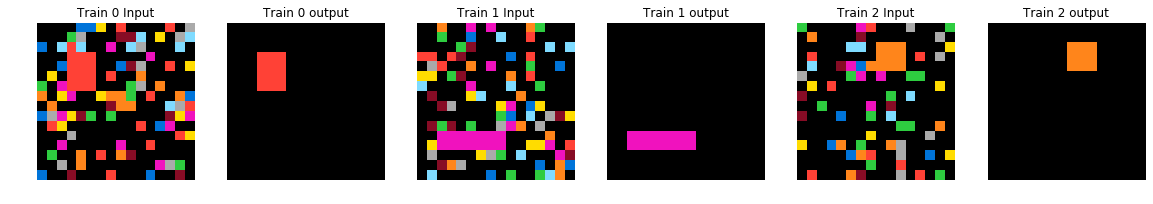

231


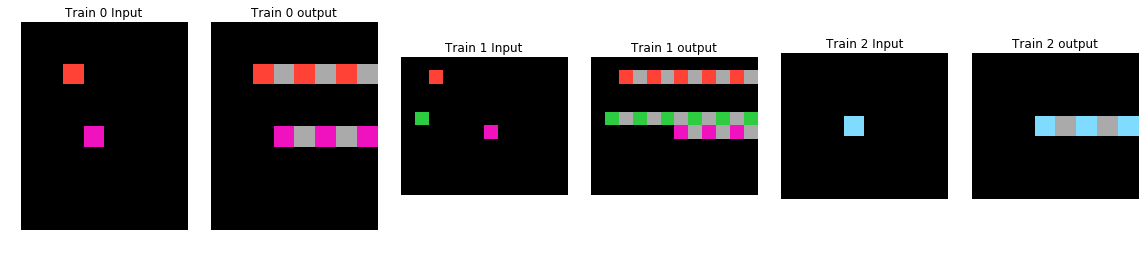

236


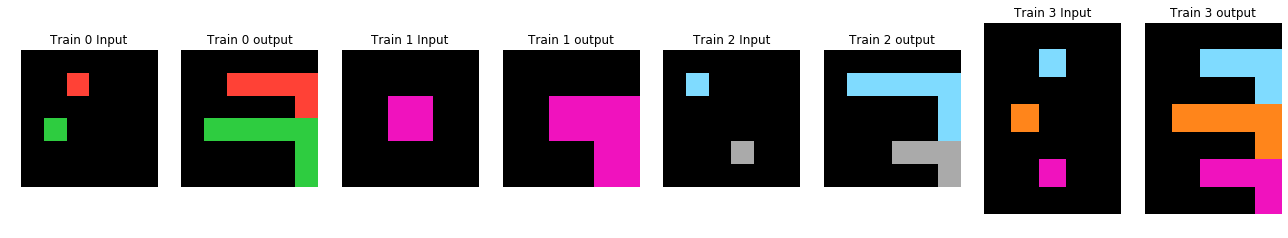

239


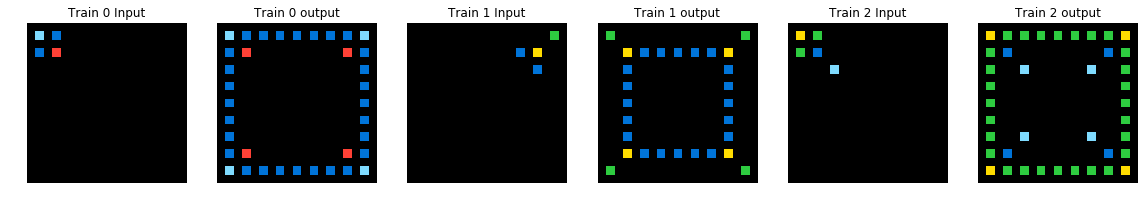

240


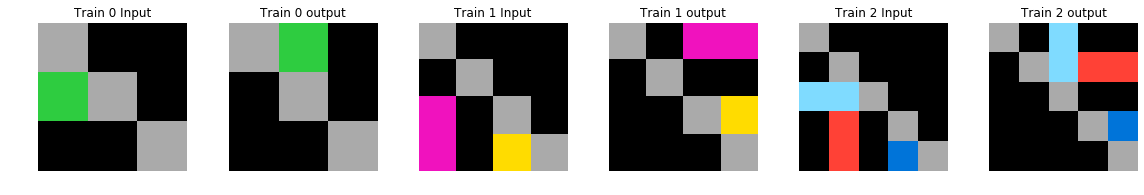

261


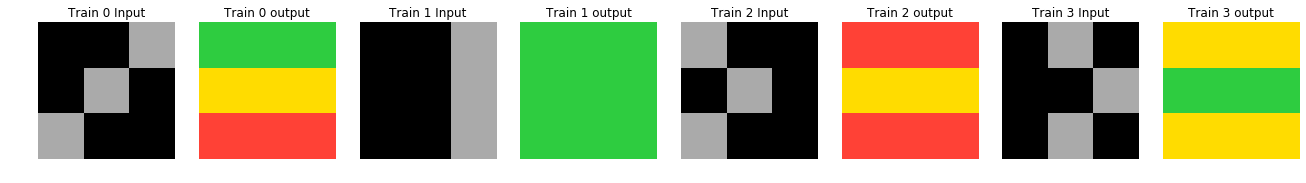

265


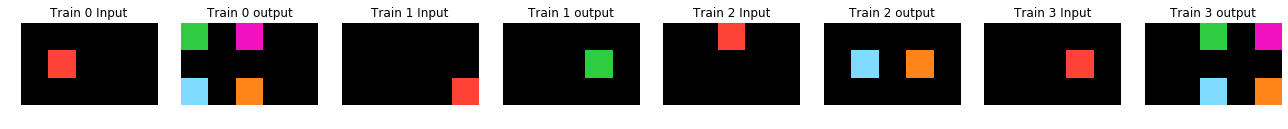

280


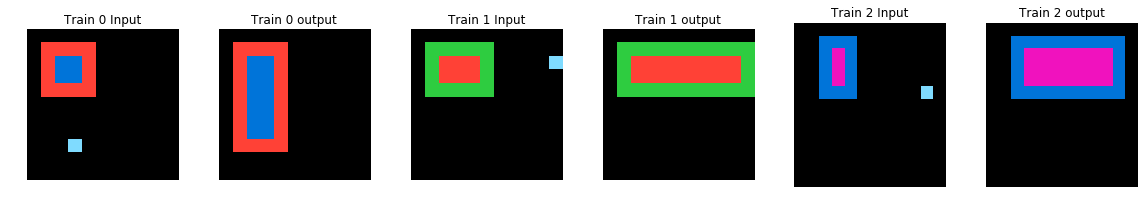

284


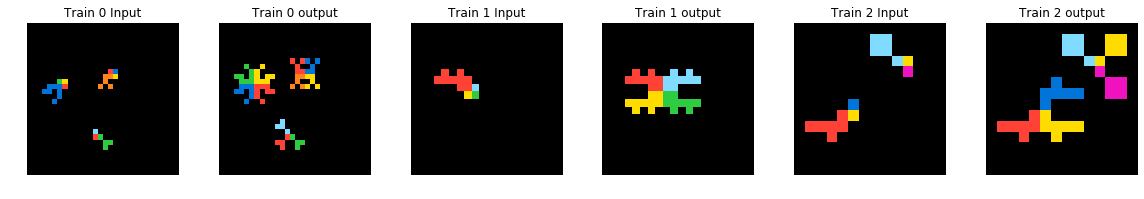

292


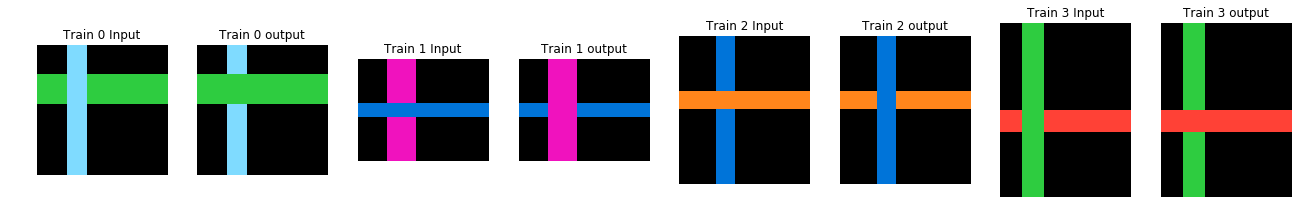

296


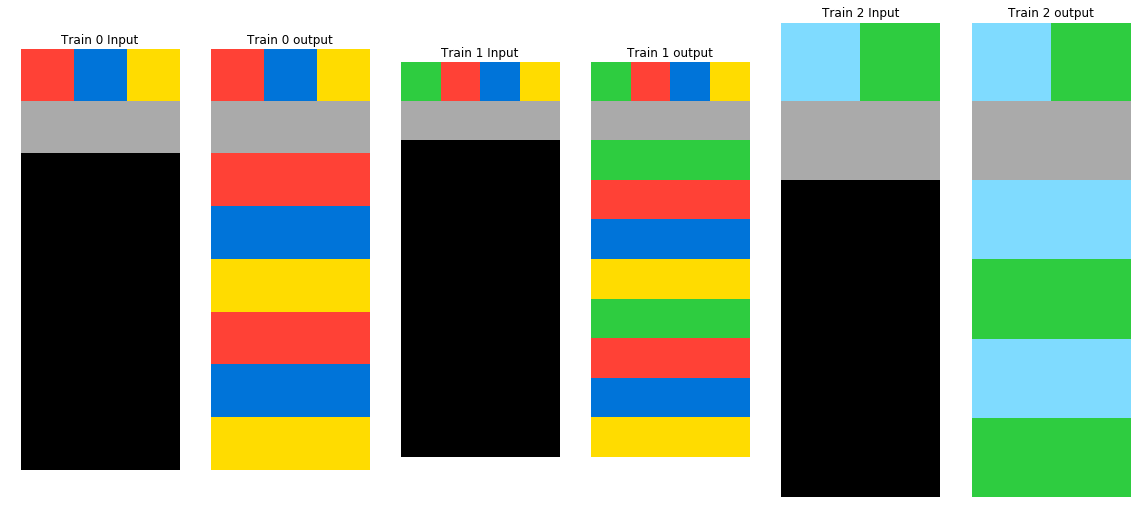

300


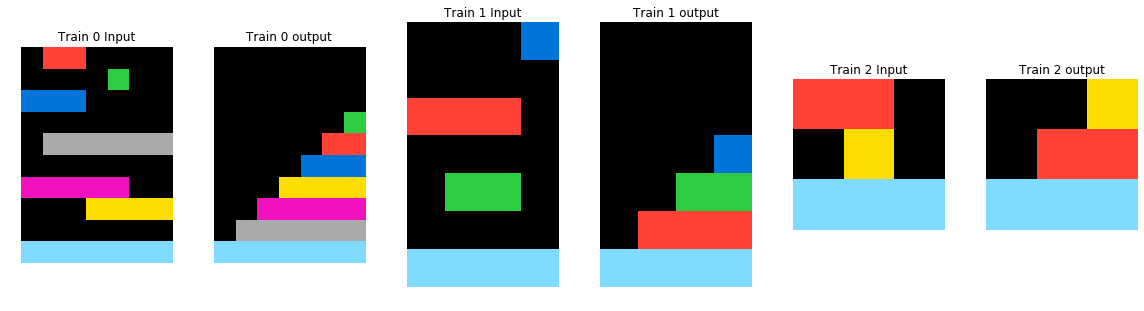

305


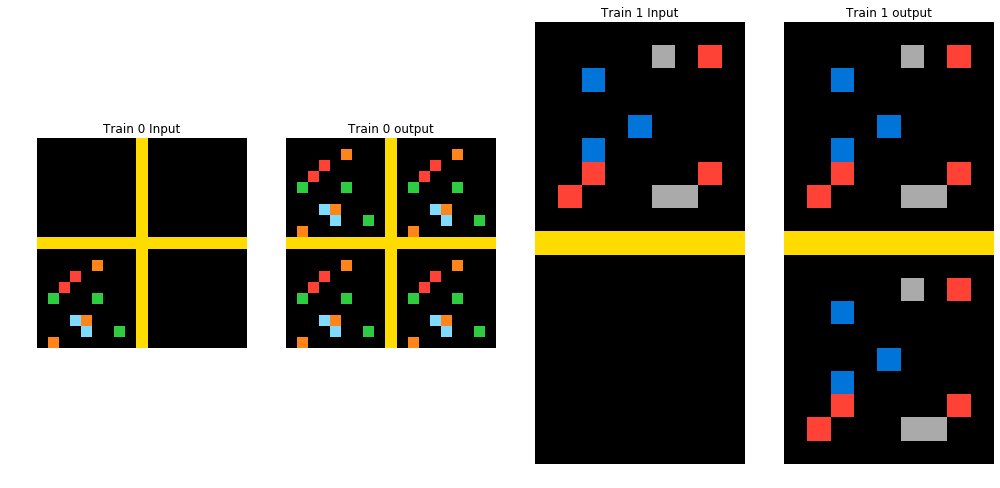

313


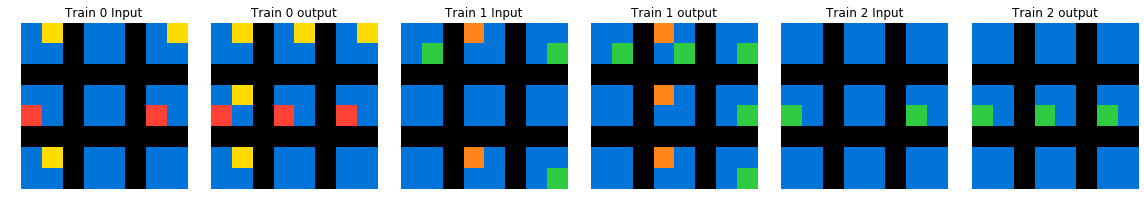

321


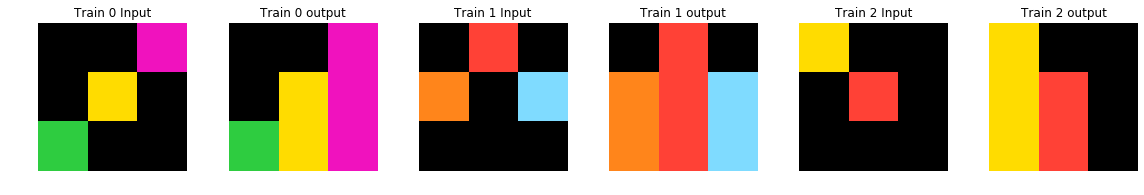

327


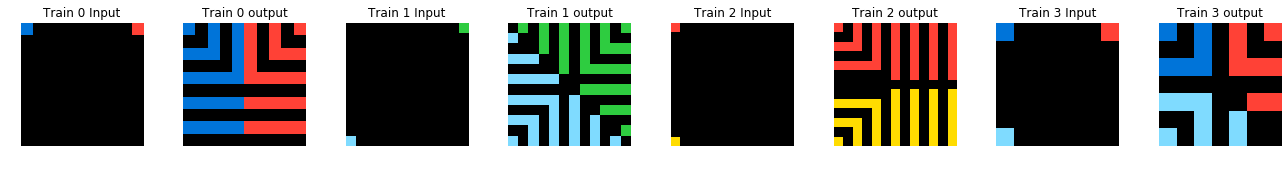

328


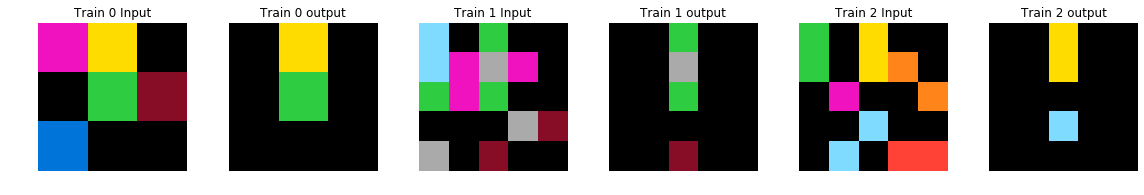

332


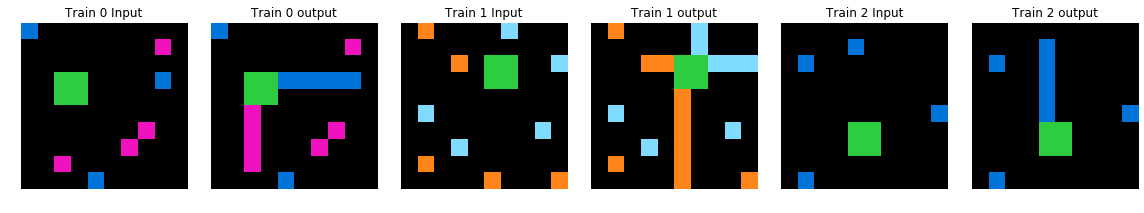

339


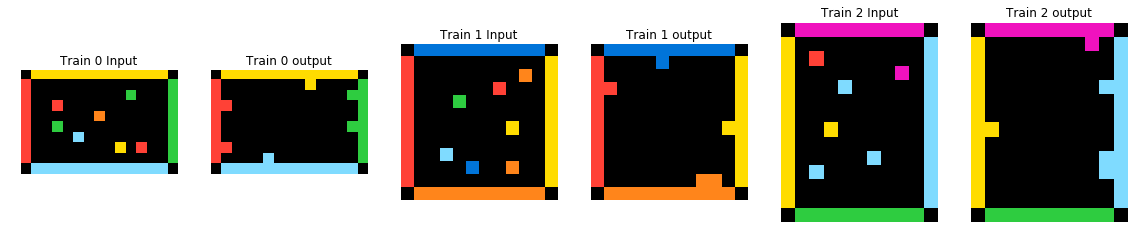

342


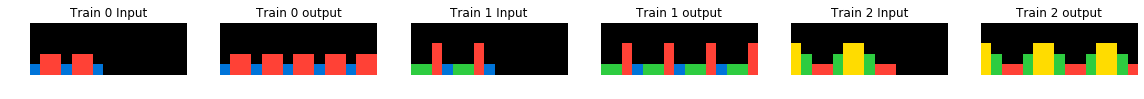

343


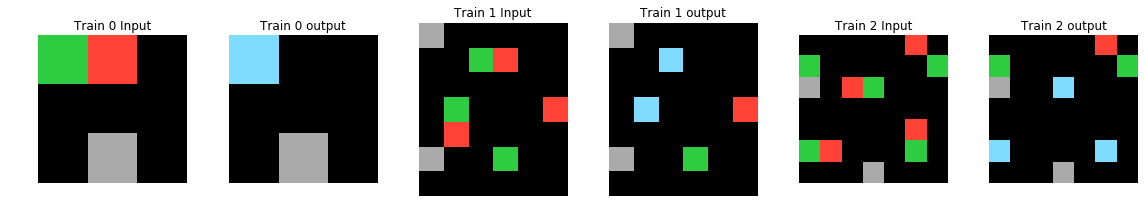

357


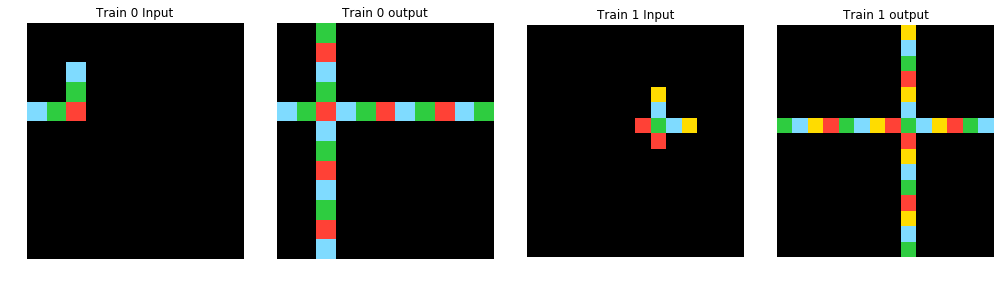

360


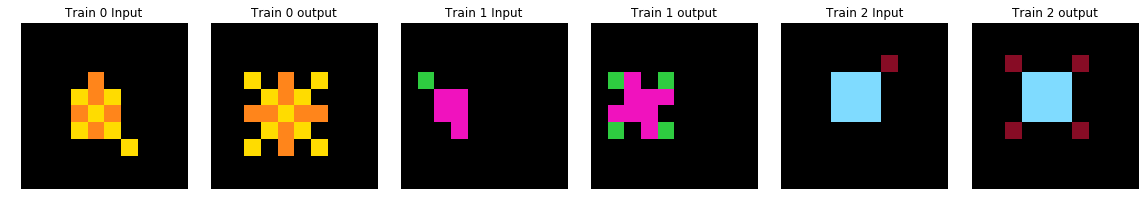

382


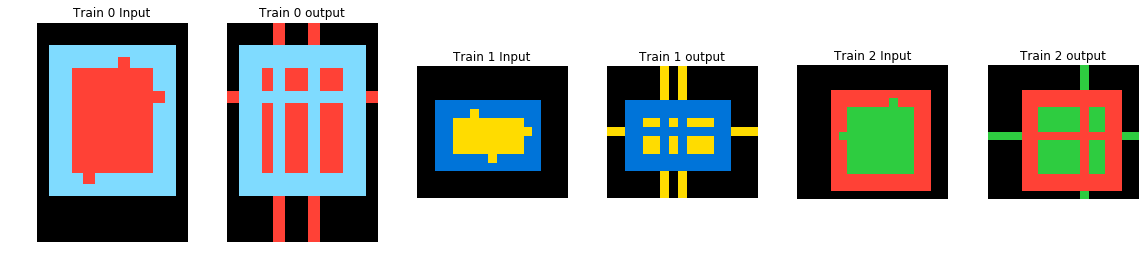

384


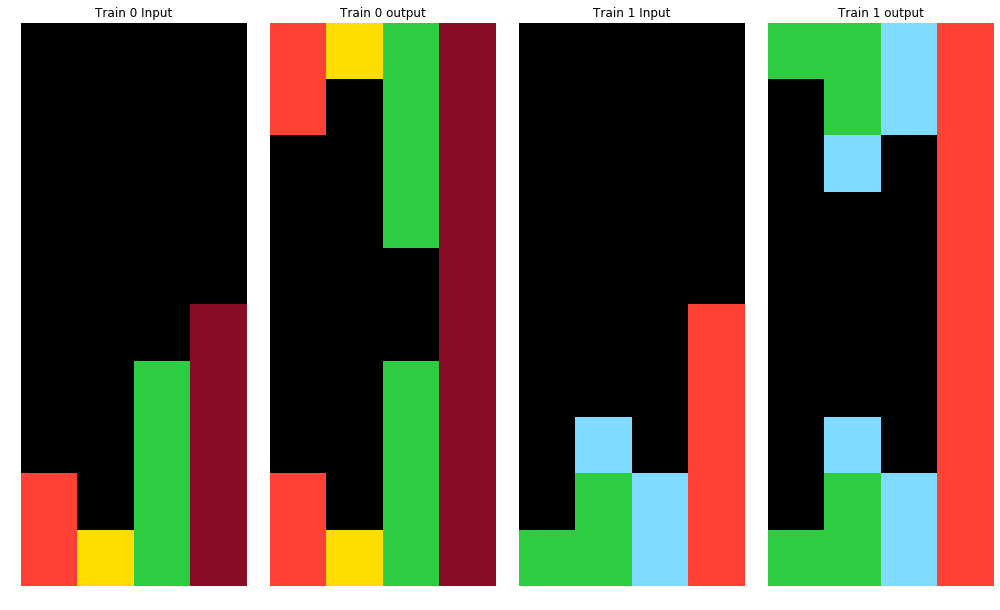

In [17]:
for n in coding_situation[0]:
    print(n)
    plot_task(tt[n])
    #plot_task(tt[n])
    #print(len(today_analysis_05272020[n].objective))

In [18]:
coding_situation = {}
coding_situation[0] = []
coding_situation[1] = []
coding_situation[2] = []


for n in range(len(today_analysis_05292020)):
    same_color_to_token = all(x == today_analysis_05292020[n].color_to_tokens[0] for x in today_analysis_05292020[n].color_to_tokens)    
    if type(today_analysis_05292020[n].problem_graph[0]) == str:
        coding_situation[0].append(n)
    elif type(today_analysis_05292020[n].problem_graph[0]) == list and same_color_to_token:
        coding_situation[1].append(n)
    else:
        coding_situation[2].append(n)
        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))
    
# 0  :  186
# 1  :  105: one code
# 2  :  109: multiple codes


0  :  186
1  :  105
2  :  109


In [19]:
deductive_coder1_to_tokenized = {}
tokenized_to_deductive_coder1 = {}
for n in coding_situation[1]:
    this_task = today_analysis_05292020[n]
    if this_task.deductive_coder1 != None:
        this_task_deductive_coder1 = str(this_task.deductive_coder1).replace('[', '').replace(']', '')
    else:
        this_task_deductive_coder1 = str(None)
        
    if len(this_task.problem_statements) == 0:
        this_task_tokenized = str(None)
    else:
        this_task_tokenized = str(this_task.problem_statements[0]).replace('[', '').replace(']', '')
        
    if this_task_deductive_coder1 not in deductive_coder1_to_tokenized.keys():
        deductive_coder1_to_tokenized[this_task_deductive_coder1] = set()
    deductive_coder1_to_tokenized[this_task_deductive_coder1].add(this_task_tokenized)
    
    if this_task_tokenized not in tokenized_to_deductive_coder1.keys():
        tokenized_to_deductive_coder1[this_task_tokenized] = set()
    tokenized_to_deductive_coder1[this_task_tokenized].add(this_task_deductive_coder1)

print(len(deductive_coder1_to_tokenized), len(tokenized_to_deductive_coder1))
# 16 58 #15 65 # 14 30 # 15 64 # 14 30

14 30


In [20]:
#list(tokenized_to_deductive_coder1.keys())

In [21]:
# Now, that we are able to globally turn a task into a series of problem graphs. It is time to epxeriment
# with solutions